# Preambule and notes

**Notes 13/08/2025**, still perfect correlation case
- do not cut in k space
- do not correct for the MAS in this framework - as in traditional PM
- check consistency of symmetry-fft, maybe take the full cube not to tackle the hastle
- do section 3
- item E is not priority for this proof of concept paper

**Notes 06/08/25 for Perfect Correlation case**
- A) improve particles displacement nearest-neighbors -> interpolation in numba or openmp + pybind11 --> **DONE**, with numba, much faster
- B) Be consistent: eg if I solve $\gamma_k$ for below the Nyquist frequency, calculate $\Phi_k$ and solve the displacement also in this range --> **DONE** but crudly
- C) 512^3 particles is hard for for a proof of concept test (maybe use fastpm as solver and low res Quijote as ref + syren)
- D) check if I take the other $\gamma_k$ roots the correlation in k space increases or not --> **DONE**, if the take the negative roots, corrected power spectra are much worse
- E) Hybrid: convolve ICs with emulator Pk to match phases/high scales or (dirty) do not resolve below given k
- F) when I interpolate in k-space, I need to incorporate the kernel for linear interpolation that is the inverse of CiC
- G) unless necessary, do not put a threshold on grad_phi in comoving space --> **DONE**
- H) can we use this code for a halo case later ? (to pursue Anirban's examples)
- I) Check the sign of gradient and that I am moving the particles in the right direction--> **DONE**, if I change the signs, the corrected power spectrum is actually "lower" than the initial one

In [1]:
#!pip install numba==0.60.0
#%matplotlib ipympl

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import get_delta, compute_Pk, compute_Bk,calculate_acc_from_phi_k, correct_pos, compute_XPk, get_roots,MAS_correction, terms_root, get_roots_gamma, terms_root_gamma, get_roots_overdensity
import scipy
import h5py, itertools
from scipy.fft import *

import progressbar
import inspect
import os
from sys import getsizeof

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.colors as colors
import colorsys
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Circle, Rectangle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib.ticker as mtick

# Pylians
import readgadget
import MAS_library as MASL
import Pk_library as PKL
import plotting_library as PL
import smoothing_library as SL
from Pk_library import MAS_correction as MAS_corr_pylians

# Emulators
import symbolic_pofk.syrenhalofit as syrenhalofit
import symbolic_pofk.linear as linear
import astropy.cosmology as cosmo

# Conveniences
format_float = lambda z: "%ip%i"%(int(z // 1), int(z%1 *10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r"$\times 10^{%i}$"%b

plt.style.use("dark_background")

import time
print("Numpy Version: ", np.__version__)
# For opti tests
import pyfftw
from numba import njit, jit, prange

import psutil
from psutil._common import bytes2human
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

--------------------------------------------------------------------------

  Local host:   a062
  Local device: mlx5_0
--------------------------------------------------------------------------
[a062.anvil.rcac.purdue.edu:577794] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


Numpy Version:  1.23.5
total memory: 251.5G
memory % used: 14.5
number of cpus : 128


# 0) Very brief summary
**A handful of equation for different test cases**

The goal is to perturbed particles positions 

\begin{align}
\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)
\end{align}

We use the convention that $\Delta$ designates the fractional overdensity field, meaning in comoving space

$\Delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \rho_\text{mean}}{\rho_\text{mean}}$
with $\rho(\mathbf{x}) = \sum_{i=1}^n \delta(\mathbf{x} - \mathbf{x}_i)$ defined with the Delta function.

The main equation for the Fourier transform of the density field of the perturbed tracer $\Delta_k^{'}$ is

\begin{align}
|\Delta^{'}_\mathbf{k}|^2 &= \Delta^{'}_\mathbf{k}\Delta^{' \ast}_\mathbf{k}  \\
&= \left[ \Delta_\mathbf{k} + k^2\phi_{\mathbf{k}} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}} 
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}  
\right) \right] \times \nonumber\\
&\left[\Delta^{\ast}_\mathbf{k} + k^2\phi_{\mathbf{k}}^{\ast} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber\\
|\Delta^{'}_\mathbf{k}|^2 &\approx_{\mathcal{O}(\phi^2)} |\Delta_{\mathbf{k}}|^2 + k^4 |\phi_{\mathbf{k}}|^2 + \frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \phi_{\mathbf{q}}
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast} \nonumber\\
 &+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\phi_{\mathbf{k}}^{\ast} +\frac{k^2}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{k}}\phi_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber 
\end{align}


**MAS kernel reminder**

In the review by [Angulo & Hahn](https://arxiv.org/abs/2112.05165), equation 62 reminds the formulae for the MAS kernel Fourier transform (p=1 for NGP and 2 for CiC)

\begin{equation}
W(k) = \left[ \mathrm{sin}_c(\frac{\pi k}{2 k_N}) \right]^p
\end{equation}

where the Nyquist wavenumber is $k_N = \frac{\pi N}{L} = \frac{1}{2}\frac{2\pi}{\Delta_x}$.

In [2]:
grid = 256
BoxSize=1000.0 # Mpc/h
#voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2

kNyquist = np.pi * grid/BoxSize

@njit
def displace_positions_nn(positions, new_positions, grad_x, grad_y, grad_z, array_length, max_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    for n in prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)

        new_positions[n,0] = np.mod(positions[n,0] + grad_x[x_index,y_index,z_index], max_length)
        new_positions[n,1] = np.mod(positions[n,1] + grad_y[x_index,y_index,z_index], max_length)
        new_positions[n,2] = np.mod(positions[n,2] + grad_z[x_index,y_index,z_index], max_length)
        
    return new_positions

@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    """
    Trilinear interpolation on a REGULAR 3D array using Numba.
    For irregular 3D grids, we could do some slight modifications

    Args:
        data (np.ndarray): The 3D array containing the data to interpolate.
        points (np.ndarray): A 2D array where each row represents query coordinates (x, y, z).
        x_coords (np.ndarray): 1D array of x-coordinates for the data grid.
        y_coords (np.ndarray): 1D array of y-coordinates for the data grid.
        z_coords (np.ndarray): 1D array of z-coordinates for the data grid.

    Returns:
        np.ndarray: An array of interpolated values corresponding to the query points.
    """
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)

    # ASSUMING REGULAR GRIDS: Pre-calculate inverse outside the loop
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0]) 

    for i in prange(num_points):
        
        x_query, y_query, z_query = points[i]

        # Indices of cube around query point
        x0_idx = np.searchsorted(x_coords, x_query, side = "left")
        y0_idx = np.searchsorted(y_coords, y_query, side = "left")
        z0_idx = np.searchsorted(z_coords, z_query, side = "left")

        # Ensure bounds are correct
        x0_idx = max(0, min(x0_idx, nx - 2))
        y0_idx = max(0, min(y0_idx, ny - 2))
        z0_idx = max(0, min(z0_idx, nz - 2))
        # x1_idx = x0_idx + 1 # not needed because regular grid !
        # y1_idx = y0_idx + 1
        # z1_idx = z0_idx + 1

        x0 = x_coords[x0_idx]
        y0 = y_coords[y0_idx]
        z0 = z_coords[z0_idx]

        # Linear interpolation weights
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv

        # Perform trilinear interpolation (hard-coded formula for 8 corners)
        c000 = data[x0_idx, y0_idx, z0_idx]
        c100 = data[x0_idx + 1, y0_idx, z0_idx]
        c010 = data[x0_idx, y0_idx + 1, z0_idx]
        c001 = data[x0_idx, y0_idx, z0_idx + 1]
        c110 = data[x0_idx + 1, y0_idx + 1, z0_idx]
        c101 = data[x0_idx + 1, y0_idx, z0_idx + 1]
        c011 = data[x0_idx, y0_idx + 1, z0_idx + 1]
        c111 = data[x0_idx + 1, y0_idx + 1, z0_idx + 1]

        interpolated_value = (
            c000 * (1 - xd) * (1 - yd) * (1 - zd) +
            c100 * xd * (1 - yd) * (1 - zd) +
            c010 * (1 - xd) * yd * (1 - zd) +
            c001 * (1 - xd) * (1 - yd) * zd +
            c110 * xd * yd * (1 - zd) +
            c101 * xd * (1 - yd) * zd +
            c011 * (1 - xd) * yd * zd +
            c111 * xd * yd * zd
        )
        interpolated_values[i] = interpolated_value

    return interpolated_values

@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z, x_c, y_c, z_c, max_length):
    '''
    3D interpolation in numba computation
    '''
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c) #"c" for comoving coordinates
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)

    # How to make periodic boundary conditions ?
    new_positions[:,0] = np.mod(positions[:,0] + nabla_x , max_length)
    new_positions[:,1] = np.mod(positions[:,1] + nabla_y , max_length)
    new_positions[:,2] = np.mod(positions[:,2] + nabla_z , max_length)
            
    return new_positions

In [3]:
# @jit(nopython=True) has for alias @njit
@njit
def fill_fourier_grid(weights_grid, k3D_radius , k_bins, weights1D):
    '''
    interpolate the gamma_k/k**2=weights1D to multiplty the three-dimensional Phi_k with
    '''
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                weights_grid[ix,iy,iz] = np.interp(k3D_radius[ix,iy,iz], k_bins, weights1D) #(x,xp,fp)
    return weights_grid

def fourier_shells_k(res, box_size, fshift = True):
    '''
    Use fhsift=True to move the zero frequency component at the center of arrays
    '''
    scale = 2*np.pi*res/box_size # k resolution
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_y = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_z = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32') # not fftshift for redundant "refreq" case
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_z = np.array(scale*np.fft.fftfreq(res), dtype='float32')

    kx, ky, kz = np.meshgrid(k_x, k_y, k_z, indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    return k_x, k_y, k_z, k_radius_grid

def plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptypes, plane, MAS, scale, 
                 colmap, dmin, dmax, redshift, titleList):  
    """
    Plot projected density (or overdensity) field for each snapshot in snapList 
    """ 
    W_k = SL.FT_filter_2D(x_max - x_min, 0, grid, "Top-Hat", 5)
    P = len(snapList)
    save_density_field = False
    
    #Initialize axes depending on the number of snapshots to analyze
    if P%2 == 0 and P > 2:
      fig, axes = plt.subplots(int(P/2), int(P/2), sharex = False, sharey = False, squeeze = False, figsize = (12,12))
    else:
      fig, axes = plt.subplots(1, P, sharex = False, sharey = False, squeeze = False, figsize = (14, 9))
      axes.shape

    #To have the same colorbar scales for all plots, we need to compute all the overdensities
    OD_list = []
    for k in np.arange(0,P):
       dx, x, dy, y, overdensity = PL.density_field_2D(snapList[k], x_min, x_max, y_min, y_max, z_min, z_max, 
                                                       grid, ptypes, plane, MAS, save_density_field) # For Pylians3
       
       #overdensity[np.where(overdensity == 0)] = np.sort(np.unique(overdensity))[1] #prevents errors with log norm
       overdensity[np.where(overdensity < dmin)] = dmin
       overdensity[np.where(overdensity > dmax)] = dmax
       overdensity = SL.field_smoothing_2D(overdensity, W_k, 4)
       OD_list.append(overdensity)

    min_OD = min(overdensity.min() for overdensity in OD_list)
    max_OD = max(overdensity.max() for overdensity in OD_list)
    
    #For each snapshot  
    for k in np.arange(0, P):
        len_x, off_x, len_y, off_y, depth, BoxSize_slice = PL.geometry(snapList[k], plane, x_min, x_max, y_min, 
                                                                       y_max, z_min, z_max)
        #Compute overdensity field with Pylians plotting library
        ax = axes.flat[k] #flat not to bother with the 2D case
        ax.set_xlim([off_x, off_y+len_x])  #set the range for the x-axis
        ax.set_ylim([off_y, off_y+len_y])  #set the range for the y-axis
        ax.set_xlabel(r'$h^{-1}{\rm Mpc}$',fontsize= 24, labelpad = 5)  #x-axis label     
        ax.set_title(titleList[k], fontsize = 22)
        ax.tick_params(axis='x', which='major', pad=2, labelsize = 22)
        ax.tick_params(axis='y', which='major', pad=2, labelsize = 22)
        
        if scale == "linear":
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     vmin=min_OD,vmax=max_OD)
            
        else:   
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     norm = LogNorm(vmin=min_OD, vmax=max_OD))
        
        #next lines adjust the colorbar dimensions next to the subplot
        divider = make_axes_locatable(ax)
        cad = divider.append_axes("right", size="8%", pad=0.05)
        plt.subplots_adjust(bottom = 0.1, top = 0.9, left = 0.09, right = 0.94, wspace = 0.35)
        cbar = plt.colorbar(ca, cax=cad)
        cbar.ax.tick_params(axis = "both", labelsize = 22)      

# 1) Setup and load data
The Quijote fiducial simulations parameters are reminded in the [documentation](https://quijote-simulations.readthedocs.io/en/latest/types.html). 
We will try to perturb a L-PICOLA snapshot, with the reference being either the Quijote simulation at the same seed or from the [symbolik_pofk](https://github.com/DeaglanBartlett/symbolic_pofk) emulator.

In [4]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8":0.834, "n_s":0.9624, "h":0.671, "Omega_b":0.049,
            "Omega_m":0.3175}

In [5]:
os.makedirs?

Signature: os.makedirs(name, mode=511, exist_ok=False)
Docstring:
makedirs(name [, mode=0o777][, exist_ok=False])

Super-mkdir; create a leaf directory and all intermediate ones.  Works like
mkdir, except that any intermediate path segment (not just the rightmost)
will be created if it does not exist. If the target directory already
exists, raise an OSError if exist_ok is False. Otherwise no exception is
raised.  This is recursive.
File:      ~/miniconda3/envs/pkcorr/lib/python3.10/os.py
Type:      function

In [6]:
redshift = 0.5
a = 1 / (1+redshift)
z_str = format_float(redshift)
seed = 1

nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003"%(z_str,seed)
nbodystr = "Quijote"

app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500"%(z_str,seed)
appstr = "LPICOLA"
ptype   = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

basedir = "/home/x-nchartier/PkCorr/Figures"

if not os.path.exists(os.path.join(basedir, appstr)):
    os.makedirs(os.path.join(basedir, appstr), exist_ok=False)

# TODO: test on fastpm sims with saved DM particles
# fpm = "/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/%i/"%seed
# file = h5py.File(os.path.join(fpm, "nbody.h5"))
# print(file.keys())
# data = file['0.666667']
# print(data.keys())
# file.close()

In [7]:
# read header for nbody
header   = readgadget.header(nbody)
BoxSize  = header.boxsize/1e3  #Mpc/h
print("BoxSize = %.1f Mpc"%BoxSize)
Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3)
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
print(r"$\Omega_m = %.4f$"%Omega_m)
Omega_l  = header.omega_l      #value of Omega_l
print(r"$\Omega_{\Lambda} = %.4f$"%Omega_l)
h        = header.hubble       #value of h
print(r"$h=%.4f$"%h)
#redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble)
Hubble_0   = 100.0*np.sqrt(Omega_m+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble_0)
print(h*Hubble_0)

# read positions, velocities and IDs of the particles
pos_nb = readgadget.read_block(nbody, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_nb = readgadget.read_block(nbody, "VEL ", ptype)     #peculiar velocities in km/s
#ids_nb = readgadget.read_block(nbody, "ID  ", ptype)-1   #IDs starting from 0

BoxSize = 1000.0 Mpc
[1.]
$\Omega_m = 0.3175$
$\Omega_{\Lambda} = 0.6825$
$h=0.6711$
132.44102461095656
100.0
67.11


In [8]:
# read header for nbody
header   = readgadget.header(app)

Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3) # sanity check

# read positions, velocities and IDs of the particles
pos_pm = readgadget.read_block(app, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_pm = readgadget.read_block(app, "VEL ", ptype)     #peculiar velocities in km/s
#ids_pm = readgadget.read_block(app, "ID  ", ptype)-1   #IDs starting from 0

[1.]


Compute overdensity fields and Power spectra from snapshots

In [9]:
# PM
delta_pm = get_delta(pos=pos_pm, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_pm, Pk_pm, _, _ = compute_Pk(delta_pm, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# N-body (=target if no emulator)
delta_nb = get_delta(pos=pos_nb, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_nb, Pk_nb, _, _ = compute_Pk(delta_nb, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X, Pk_X, _, _ = compute_XPk(delta_pm, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk = Pk_X/np.sqrt(Pk_pm*Pk_nb)


Using CIC mass assignment scheme
Time taken = 1.814 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Using CIC mass assignment scheme
Time taken = 1.877 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Computing power spectra of the fields...
Time FFTS = 0.59
Time loop = 0.36
Time taken = 0.95 seconds



Computing density field...
Expected mass = 1.1220728e+18
Computed mass = 1.1220731e+18
mass density = 8.81221e+10
0.087317914 < rho/<rho> < 23.772453

Computing density field...
Expected mass = 1.1222171e+18
Computed mass = 1.1222175e+18
mass density = 8.81221e+10
0.13087106 < rho/<rho> < 18.21459


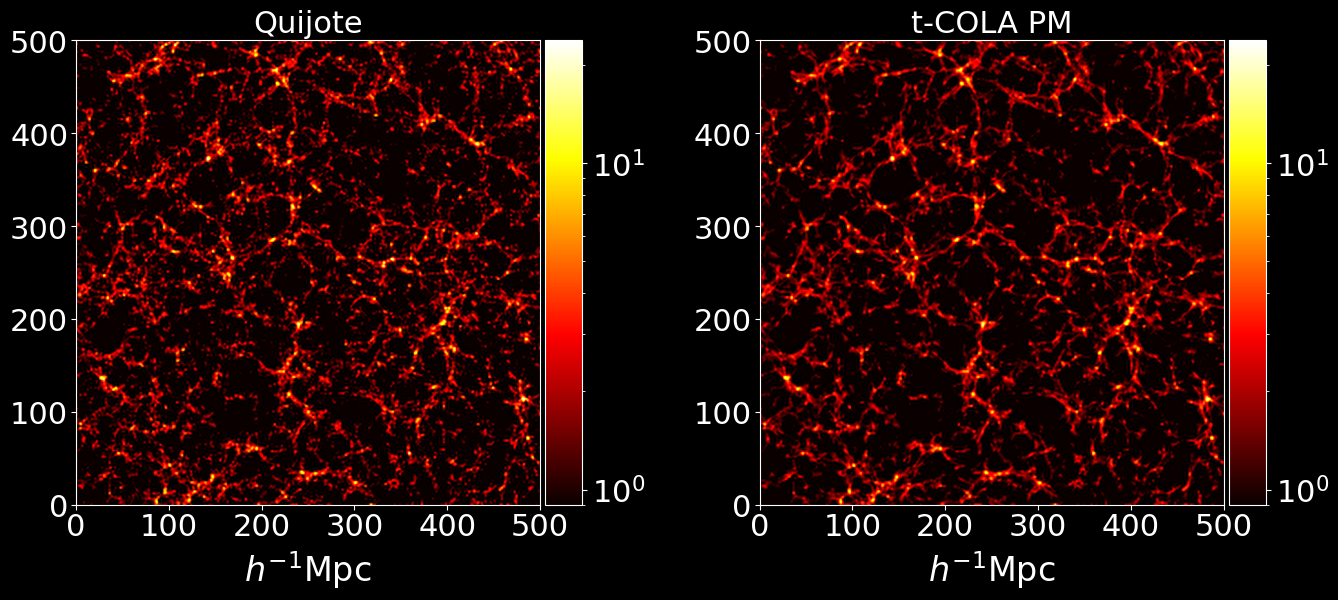

In [10]:
snapList = [nbody, app]
# For plotting
indicateNyquist = False
dmin = 0.9 ;dmax = 80
#%% 2D PROJECTED OVERDENSITY FIELD 
x_min = 0.0;  x_max = 500.0
y_min = 0.0;  y_max = 500.0
z_min = 40.0;  z_max = 90.0

plane = 'XY'
scale = 'log' #'linear' or 'log'
colmap = 'hot'
axList = ["Quijote", "t-COLA PM"]

plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptype, plane, MAS, scale, colmap,
                dmin, dmax, redshift, axList)

In [11]:
# Emulate P(k)
pk_halofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial',
                extrapolate=True, which_params='Bartlett', add_correction=False)

pk_syrenhalofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                    Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial', 
                    extrapolate=True, which_params='Bartlett', add_correction=True)



/home/x-nchartier/miniconda3/envs/pkcorr/lib/python3.10/site-packages/symbolic_pofk/linear.py:244: UserWarning: Using Bartlett et al. formula outside tested regime. Due to problems with the Colossus Eisenstein & Hu fit on                 large scales (typically a 2 percent offset), it is strongly recommended to use extrapolate=False.
  warnings.warn(


In [12]:
# Pylians uses the diagonal of the cube for kmax, not k Nyquist !
print(k_pm.max())
print(k_pm.shape)
print(np.pi *grid/BoxSize)
print(np.pi *grid/BoxSize * np.sqrt(3))

1.3902843163141774
(221,)
0.8042477193189871
1.3929979117318794


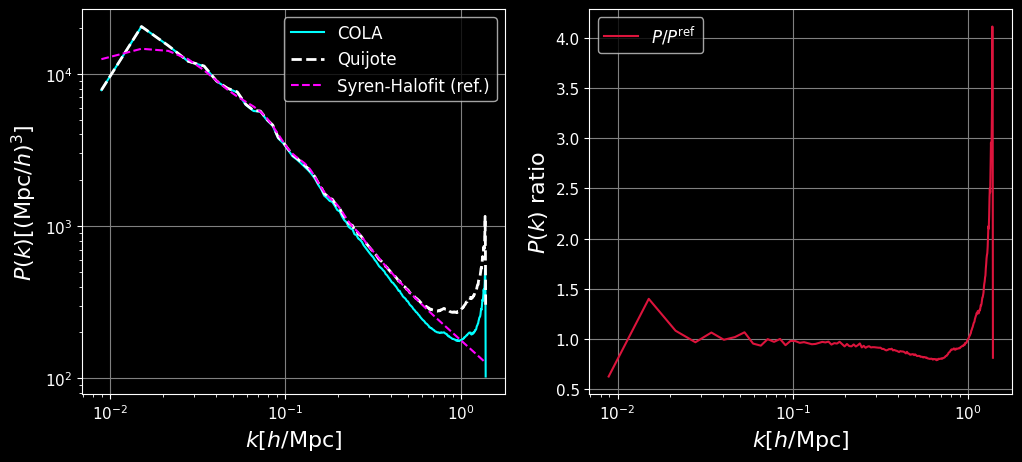

In [13]:
#plt.style.use("default")
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "white", zorder = 4)
ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "--", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)

ax2.plot(k_pm, Pk_pm/pk_syrenhalofit, label='$P/P^{\mathrm{ref}}$', zorder = 3, color = "crimson")
ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.tick_params(labelsize = 11)

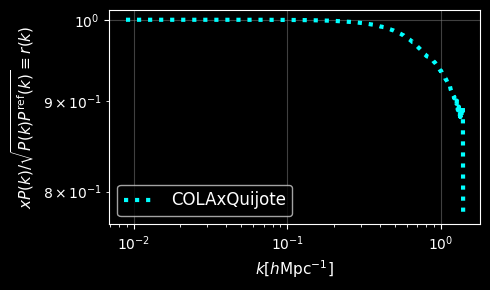

In [14]:
fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_X, rk, ':', label='COLAxQuijote', zorder= 10, lw = 3, color = "cyan")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

# 2) Dark matter perturbation tests

## 2-1) Perfect correlation case
$\Phi(k) = \frac{\gamma_k}{k^2} \Delta_k$

Pick sign of gamma k so that we move towards higher density locations

If we take the expectation with respect to Delta, power spectrum, as well as bispectum and trispectrum terms appear

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx (2\pi)^3P(k) + \gamma_k^2(2\pi)^3P(k) +\frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} \frac{\gamma_{q'}\gamma_{q}}{q^2 q'^{2}}(\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}
 \Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast}] \nonumber \\
&+ 2 \operatorname{Re}\left[ (2\pi)^3 \gamma_k P(k) +\frac{1}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \gamma_k \frac{\gamma_q}{q^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}] \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]
    +\frac{1}{2V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot (\mathbf{k} -\mathbf{q}))\frac{\gamma_q}{q^2} \frac{\gamma_{|k-q|}}{|k-q|^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{k-q}}^{\ast}]
 \right. \nonumber \\
 &+ \left. \frac{1}{2V^2} \sum_{\mathbf{q}, \mathbf{q'}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot \mathbf{q'})\frac{\gamma_q}{q^2} \frac{\gamma_q'}{q'^2}\mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast}] \right]
\end{align}

**Question**

Can we afford dropping bispectrum and trispectrum terms and simply solving for the polynomial below ? 
\begin{equation}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} = P(k) + \gamma_k^2 P(k) + 2 \gamma_k P(k) 
\end{equation}

In [112]:
# If emulator, the target Power spectrum is a mean emulator calculation
emulator = False
Pk_target = pk_syrenhalofit if emulator else Pk_nb

high_roots = True # take roots_e[:,1].real if True, roots_e[:,0].real otherwise

tstr = "emul" if emulator else "sim"
rstr = "posroots" if high_roots else "negroots"

fig_fold = os.path.join(basedir, appstr, "corr_%s_%s"%(tstr, rstr))

if not os.path.exists(fig_fold):
    os.makedirs(os.path.join(fig_fold), exist_ok=False)

# Limit the analysis to k Nyquist
kN = np.pi *grid/BoxSize
inds = np.where(k_nb <= kN)
k = k_nb[inds]
print(k.shape)

(127,)


(127, 3)


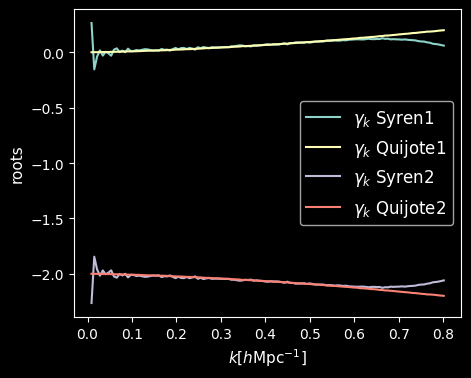

In [113]:
# With gamma convention
roots_nb, coeffs_nb=get_roots_gamma(k, Pk_pm[inds], Pk_nb[inds])
roots_e, coeffs_e=get_roots_gamma(k, Pk_pm[inds], pk_syrenhalofit[inds])

# "Positive" roots
gamma_k_e1 = roots_e[:,1].real
gamma_k_nb1 = roots_nb[:,1].real

# "Lower" roots
gamma_k_e2 = roots_e[:,0].real
gamma_k_nb2 = roots_nb[:,0].real
print(coeffs_e.shape)

fig, ax = plt.subplots(figsize = (5,4), ncols = 1, nrows= 1)
ax.plot(k, gamma_k_e1, label=r'$\gamma_k$' + " Syren1")
ax.plot(k, gamma_k_nb1, label=r'$\gamma_k$' + " Quijote1")
ax.plot(k, gamma_k_e2, label=r'$\gamma_k$' + " Syren2")
ax.plot(k, gamma_k_nb2, label=r'$\gamma_k$' + " Quijote2")
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
ax.set_ylabel(r"roots", fontsize = 11)
#plt.tight_layout()
plt.savefig(os.path.join(fig_fold, "gammak_roots.pdf"), bbox_inches = "tight")

# Sets the roots for later with the same variable names
if emulator:
    Pk_target = pk_syrenhalofit
    gamma_k = gamma_k_e1 if high_roots else gamma_k_e2
    coeffs = coeffs_e
    roots = roots_e
else:
    Pk_target = Pk_nb
    gamma_k = gamma_k_nb1 if high_roots else gamma_k_nb2
    coeffs = coeffs_nb
    roots = roots_nb

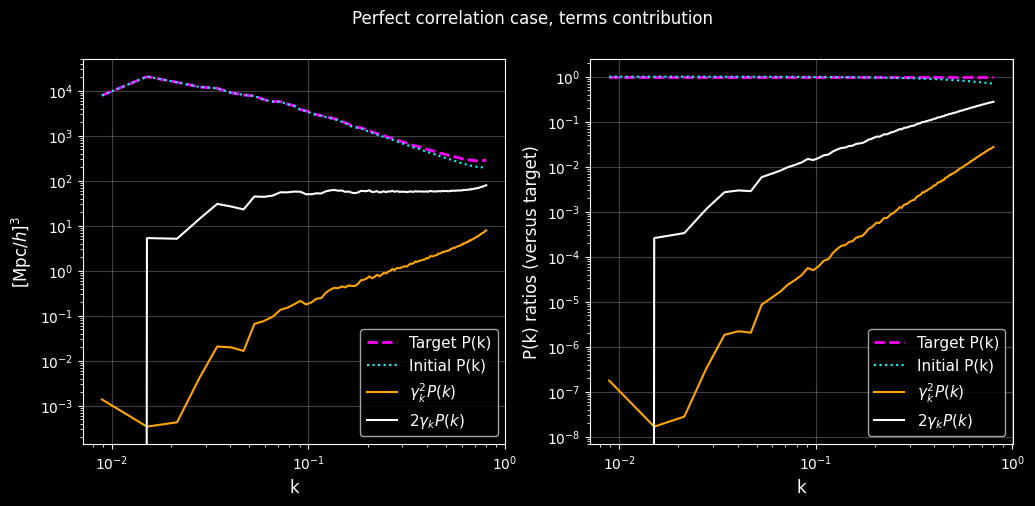

In [114]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k, Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")
plt.savefig(os.path.join(fig_fold, "Pk_setup_comparison.pdf"), bbox_inches = "tight")

### FFT tests and plots: MAS and k radius
I take the occasion to compare the computation times for two different ways of using pyfftw.

In [115]:
# Perform the FFT for delta(k)
#N_CPU = 16
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]

NCPU_list = [1,2,4,8,16,32]
ct1_list = []
ct2_list = []
ct3_list = []

for N_CPU in NCPU_list:
    
    start = time.time()
    # Initialize
    arr_in  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    # Fill data in advance with builders interface
    arr_in[:] =  delta_pm.astype(prec_in)
    # Instantiate FFTW object
    fftw_object = pyfftw.builders.fftn(arr_in,  axes=(0,1,2), threads=N_CPU)
    # Compute transform
    delta_pm_fourier_alt = fftw_object()
    end = time.time()
    print("First computation: %.3f seconds"%(end-start))
    ct1_list.append(end-start)
    
    # ALTERNATIVE COMPUTATION
    start = time.time()
    a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
    # plan FFTW
    fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                            flags=('FFTW_ESTIMATE',),
                            direction='FFTW_FORWARD', threads=N_CPU)
    # put input array into delta_r and perform FFTW
    a_in[:] = delta_pm.astype(prec_in)
    delta_pm_fourier = fftw_plan(a_in,a_out)
    end = time.time()
    ct2_list.append(end-start)
    print("Second computation: %.3f seconds"%(end-start))

    # With numpy interface
    start = time.time()
    delta_pm_fourier_np = pyfftw.interfaces.numpy_fft.fftn(delta_pm.astype(prec_in))
    end = time.time()
    ct3_list.append(end-start)
    print("Numpy interface: %.3f seconds"%(end-start))

    print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
    print("Norm of difference fftw np: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_np)), "\n")

    if N_CPU != NCPU_list[-1]:
        del delta_pm_fourier, delta_pm_fourier_alt, arr_in, a_in, fftw_object, fftw_plan


print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
print("Norm of difference fftw np: %.3f"%(np.linalg.norm(np.fft.fftshift(delta_pm_fourier)-np.fft.fftshift(delta_pm_fourier_np))), "\n")    
del delta_pm_fourier_alt, delta_pm_fourier_np

First computation: 1.208 seconds
Second computation: 1.122 seconds
Numpy interface: 1.171 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.663 seconds
Second computation: 0.606 seconds
Numpy interface: 1.135 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.404 seconds
Second computation: 0.361 seconds
Numpy interface: 1.156 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.270 seconds
Second computation: 0.215 seconds
Numpy interface: 1.151 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.203 seconds
Second computation: 0.144 seconds
Numpy interface: 1.143 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.202 seconds
Second computation: 0.127 seconds
Numpy interface: 1.165 seconds
Norm of difference fftw 2 m

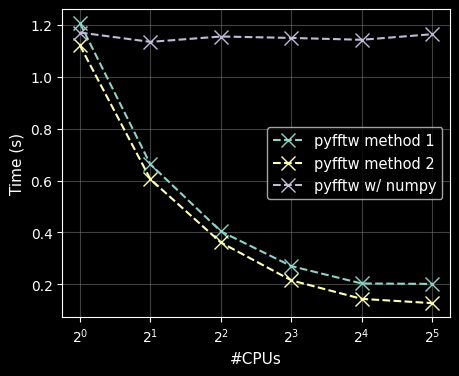

In [116]:
fig, ax = plt.subplots(figsize = (5,4))
ax.plot(NCPU_list, ct1_list, label = "pyfftw method 1", marker ="x", markersize = 10, ls="--")
ax.plot(NCPU_list, ct2_list, label = "pyfftw method 2", marker ="x", markersize = 10, ls="--")
ax.plot(NCPU_list, ct3_list, label = "pyfftw w/ numpy", marker ="x", markersize = 10, ls="--")
ax.set_xscale('log', base=2)
ax.set_ylabel("Time (s)", fontsize = 11)
ax.set_xlabel("#CPUs", fontsize = 11)
ax.set_yscale('linear')
ax.legend(fontsize = 10.5, loc = "best")
ax.grid(color = "gray", alpha =0.5)
#plt.tight_layout()
plt.savefig(os.path.join(fig_fold, "pyfftw_tests.pdf"), bbox_inches = "tight")

About np.meshgrid:
In the 2-D case with inputs of length M and N, the outputs are of shape (N, M) for ‘xy’ indexing and (M, N) for ‘ij’ indexing. In the 3-D case with inputs of length M, N and P, outputs are of shape (N, M, P) for ‘xy’ indexing and (M, N, P) for ‘ij’ indexing

In [117]:
# Keep fftshift True for consistency later on
fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
kx_g, ky_g, kz_g = np.meshgrid(kx_v, ky_v, kz_v, indexing = "ij")
print(k_radius.shape)
print(k_radius.max())
print(kx_v.min(), kx_v.max())

# Compute MAS correction factors - we first need 3d arrays

# 04/09/2025: MAS definition is wrt k/kN, eq 62 Angulo and Hahn review
print(kNyquist)
MAS_factor_kx = MAS_correction(np.pi/2*kx_g/kNyquist, MAS_index)
MAS_factor_ky = MAS_correction(np.pi/2*ky_g/kNyquist, MAS_index)
MAS_factor_kz = MAS_correction(np.pi/2*kz_g/kNyquist, MAS_index)

# MAS_factor_kx = MAS_correction(kx_g, MAS_index)
# MAS_factor_ky = MAS_correction(ky_g, MAS_index)
# MAS_factor_kz = MAS_correction(kz_g, MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz
del MAS_factor_kx, MAS_factor_ky, MAS_factor_kz
print(delta_pm_fourier.dtype)
print(MAS_factor.min(), MAS_factor.max())
print(abs(delta_pm_fourier).min(), abs(delta_pm_fourier).max())

(256, 256, 256)
1.392998
-0.80424774 0.7979645
0.8042477193189871
complex64
1.0 15.021714
0.0040893555 186201.86


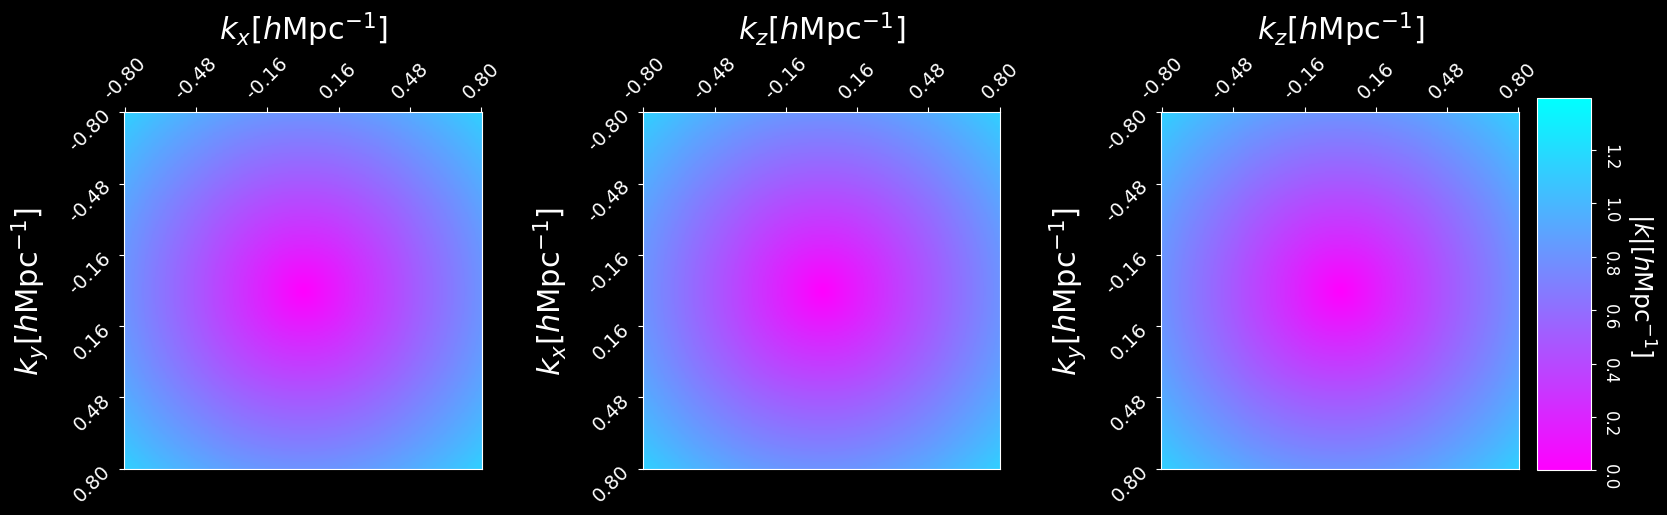

In [118]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0] ;ax2 = axes[1];ax3 = axes[2]
div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(k_radius[:,:,indcut],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k_radius.max()*fact))
else:
    im1 = ax1.matshow(k_radius[:,:,indcut],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k_radius.max()*fact)

# Colorbar setting # can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.get_yaxis().labelpad = 28
myCbar.set_ylabel(r"$|k| [h\mathrm{Mpc}^{-1}]$", fontsize = 18, rotation = 270)

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)
plt.savefig(os.path.join(fig_fold, "k_modulus_check.pdf"), bbox_inches = "tight")

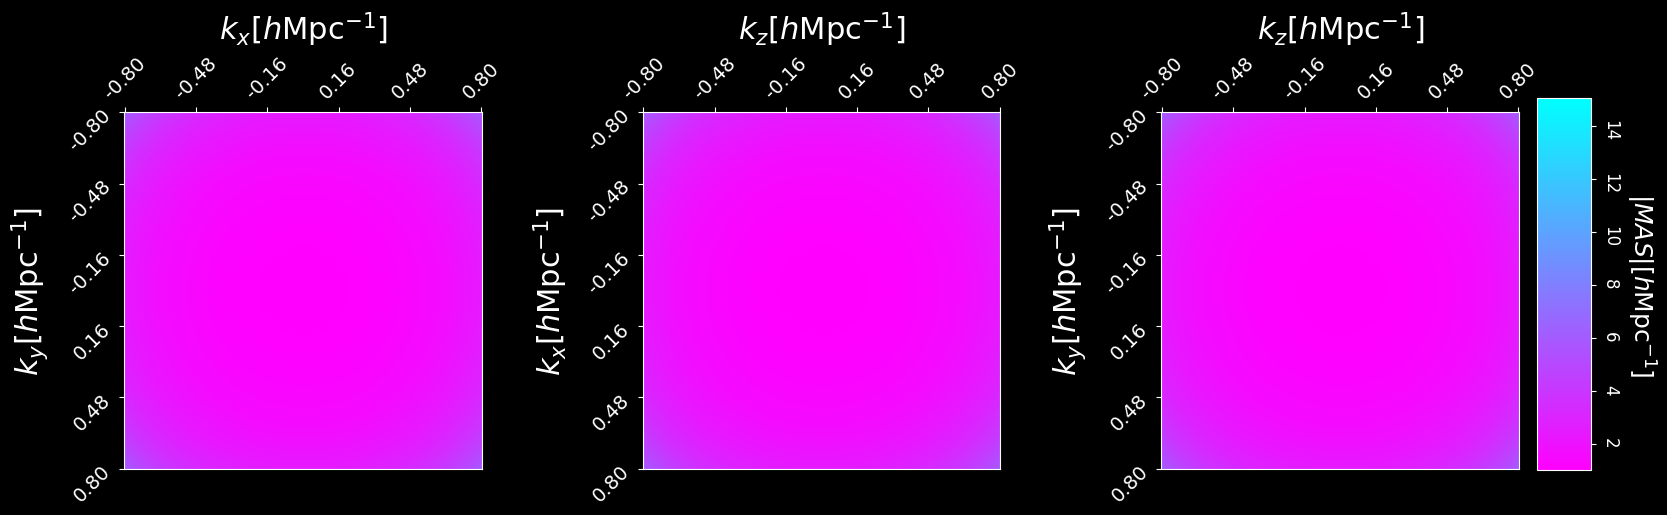

In [119]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0] ;ax2 = axes[1];ax3 = axes[2]
div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(MAS_factor[:,:,indcut],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=MAS_factor.max()*fact))
    im2 = ax2.matshow(MAS_factor[:,indcut,:],cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1, vmax=MAS_factor.max()*fact))
    im3 = ax3.matshow(MAS_factor[indcut,:,:],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=MAS_factor.max()*fact))
else:
    im1 = ax1.matshow(MAS_factor[:,:,indcut],cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = MAS_factor.max()*fact)
    im2 = ax2.matshow(MAS_factor[:,indcut,:],cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = MAS_factor.max()*fact)
    im3 = ax3.matshow(MAS_factor[indcut,:,:],cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = MAS_factor.max()*fact)

# Colorbar setting # can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.get_yaxis().labelpad = 28
myCbar.set_ylabel(r"$|MAS| [h\mathrm{Mpc}^{-1}]$", fontsize = 18, rotation = 270)

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)
plt.savefig(os.path.join(fig_fold, "MAS_modulus_check.pdf"), bbox_inches = "tight")

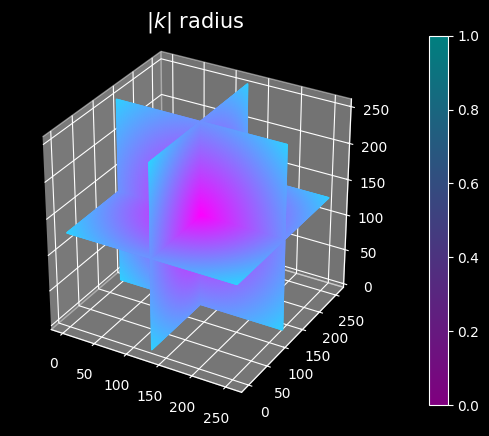

<Figure size 640x480 with 0 Axes>

In [120]:
def plot_quadrants(ax, array, fixed_coord, cmap):
    """For a given 3d *array* plot a plane with *fixed_coord*, using four quadrants."""
    nx, ny, nz = array.shape
    index = {
        'x': (nx // 2, slice(None), slice(None)),
        'y': (slice(None), ny // 2, slice(None)),
        'z': (slice(None), slice(None), nz // 2),
    }[fixed_coord]
    plane_data = array[index]

    n0, n1 = plane_data.shape
    quadrants = [
        plane_data[:n0 // 2, :n1 // 2],
        plane_data[:n0 // 2, n1 // 2:],
        plane_data[n0 // 2:, :n1 // 2],
        plane_data[n0 // 2:, n1 // 2:]
    ]

    min_val = array.min()
    max_val = array.max()

    cmap = plt.get_cmap(cmap)

    for i, quadrant in enumerate(quadrants):
        facecolors = cmap((quadrant - min_val) / (max_val - min_val))
        #facecolors = cmap(quadrant)
        if fixed_coord == 'x':
            Y, Z = np.mgrid[0:ny // 2, 0:nz // 2]
            X = nx // 2 * np.ones_like(Y)
            Y_offset = (i // 2) * ny // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X, Y + Y_offset, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
        elif fixed_coord == 'y':
            X, Z = np.mgrid[0:nx // 2, 0:nz // 2]
            Y = ny // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X + X_offset, Y, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5,cmap = cmap)
        elif fixed_coord == 'z':
            X, Y = np.mgrid[0:nx // 2, 0:ny // 2]
            Z = nz // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Y_offset = (i % 2) * ny // 2
            A = ax.plot_surface(X + X_offset, Y + Y_offset, Z, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
    return A


def figure_3D_array_slices(array,  titlestr,cmap=None):
    """Plot a 3d array using three intersecting centered planes."""
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(array.shape)
    A = plot_quadrants(ax, array, 'x', cmap=cmap)
    plot_quadrants(ax, array, 'y', cmap=cmap)
    plot_quadrants(ax, array, 'z', cmap=cmap)
    plt.title(titlestr, fontsize = 15)
    fig.colorbar(A, pad = 0.1)
    # divider = make_axes_locatable(ax)
    # cad = divider.append_axes("right", size="8%", pad=0.05)
    # mappable = plt.cm.ScalarMappable(cmap=cmap, cax = cad)
    # plt.colorbar(mappable)
    return fig, ax

figure_3D_array_slices(k_radius,r"$|k|$" + " radius", cmap='cool_r')
plt.show()
plt.savefig(os.path.join(fig_fold, "k_radius_3D.pdf"), bbox_inches = "tight")

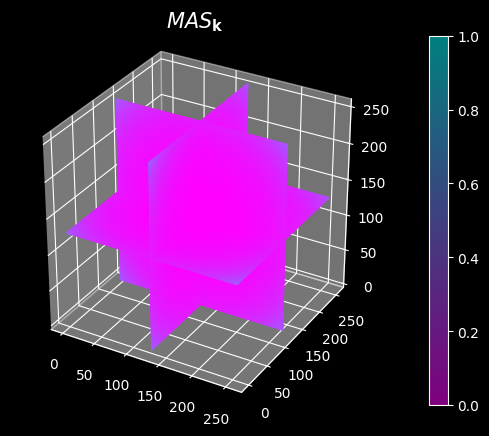

<Figure size 640x480 with 0 Axes>

In [121]:
figure_3D_array_slices(MAS_factor,r"$MAS_{\mathbf{k}}$", cmap='cool_r')
plt.show()
plt.savefig(os.path.join(fig_fold, "MAS_k_check.pdf"), bbox_inches = "tight")

### Compute $\Delta_{\mathbf{k}}$

In [122]:
delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

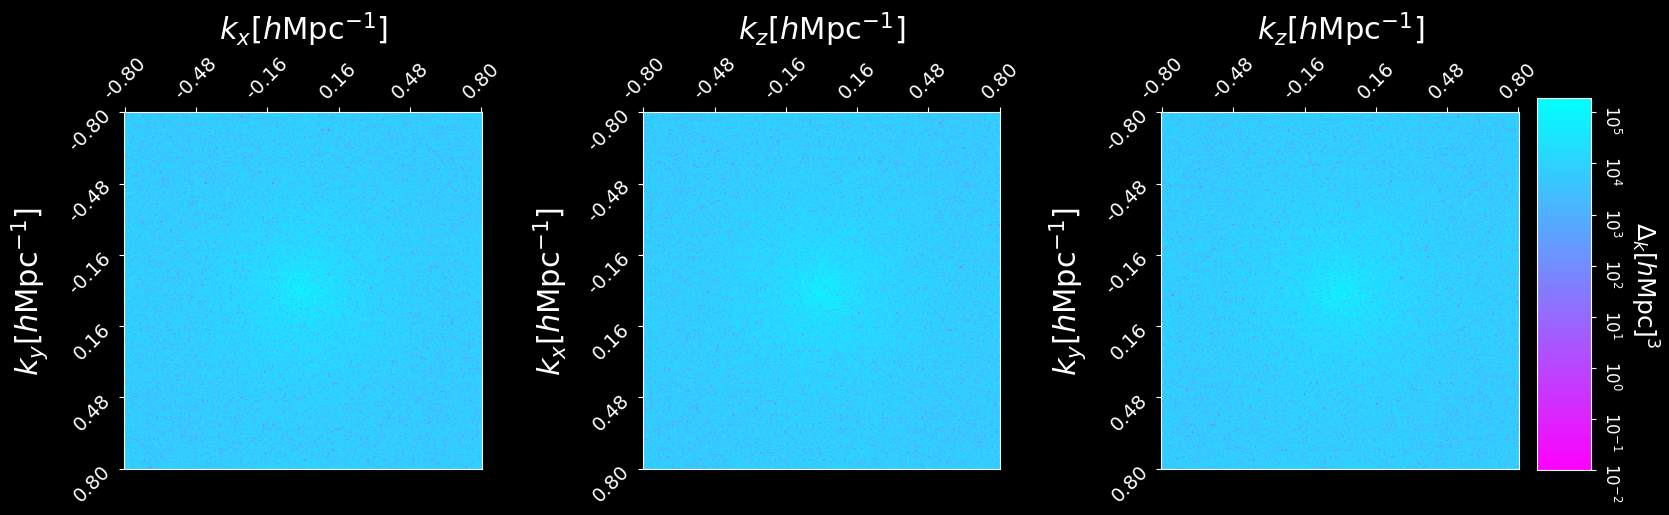

In [123]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)

ax1 = axes[0]; ax2 = axes[1] ; ax3 = axes[2]

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = True
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(delta_k[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]), cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
else:
    im1 = ax1.matshow(abs(delta_k[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k[:,:,0]).max())
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k).max())
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax =abs(delta_k).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\Delta_k [h\mathrm{Mpc}]^{3}$", fontsize = 18, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

### Compute $\frac{\gamma_k}{k^2} \times \Delta_k \equiv \Phi_k$ in 3D

In [124]:
print(k.shape == gamma_k.shape)
weights1D = gamma_k/(k**2)

# Put gamma_k weights in 3D
print(k.max())
print(kx_v.max())
print(k_radius.max())
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
phi_k = weights_grid* delta_k
#phi_k = weights_grid*delta_pm_fourier_shift
# Only include corrections until K Nyquist ?
#phi_k[np.where(k_radius >= kN)]=0.0

True
0.8010491096592355
0.7979645
1.392998


[ 49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66
  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138
 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174
 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192
 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207]


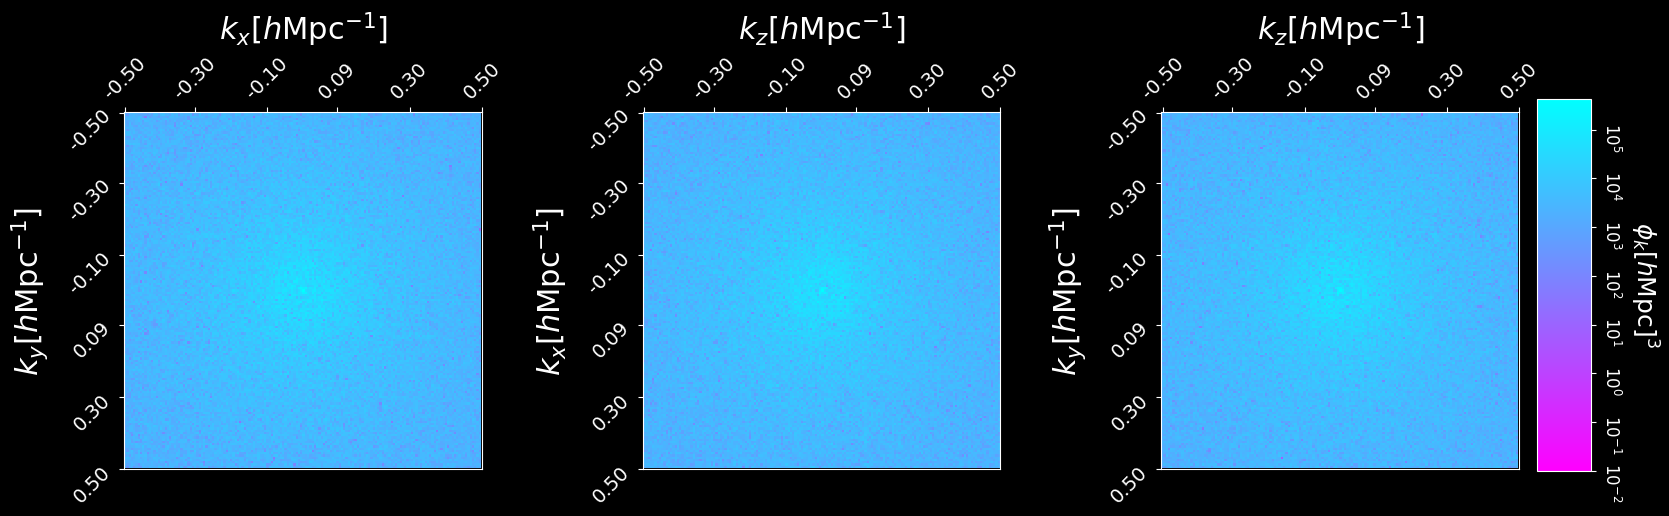

In [125]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] ; ax3 = axes[2]

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

kmip = -0.50
kmap = -kmip

indp = np.where((kx_v>=kmip)&(kx_v<=kmap))[0]
print(indp)
logscale = True
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(phi_k[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(phi_k).max()))
    im2 = ax2.matshow(abs(phi_k[indp.min():indp.max(),indcut,indp.min():indp.max()]),cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=abs(phi_k).max()))
    im3 = ax3.matshow(abs(phi_k[indcut,indp.min():indp.max(),indp.min():indp.max()]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(phi_k).max()))
else:
    im1 = ax1.matshow(abs(phi_k[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(phi_k[:,:,0]).max())
    im2 = ax2.matshow(abs(phi_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(phi_k).max())
    im3 = ax3.matshow(abs(phi_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax =abs(phi_k).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\phi_k [h\mathrm{Mpc}]^{3}$", fontsize = 18, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[indp][labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[indp][labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

In [126]:
print(delta_k.nbytes/(1024**2), "Mb")
print(pos_pm.nbytes/(1024**2), "Mb")
try:
    del pos_nb
except:
    pass

128.0 Mb
1536.0 Mb


### Compute $\nabla \Phi(x)$
For that, we compute the gradient in Fourier space and then IFFT.

In [127]:
grad_x_fourier = -1.0j*kx_v[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier = -1.0j*ky_v[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier = -1.0j*kz_v[np.newaxis, np.newaxis, :] * phi_k

grad_x_fourier_g = -1.0j*kx_g * phi_k
grad_y_fourier_g = -1.0j*ky_g * phi_k
grad_z_fourier_g = -1.0j*kz_g * phi_k

# The two computations should be exactly the same
print((grad_x_fourier == grad_x_fourier_g).all())
print((grad_y_fourier == grad_y_fourier_g).all())
print((grad_z_fourier == grad_z_fourier_g).all())

True
True
True


In [128]:
# Initialize
start = time.time()
N_CPU = 16
arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)


fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)


grad_x_real = fftw_planx(arr_inx, arr_outx)
grad_y_real = fftw_plany(arr_iny, arr_outy)
grad_z_real = fftw_planz(arr_inz, arr_outz)
end=time.time()
print("Computation: %.3f seconds"%(end-start))
print(grad_x_real.dtype)

Computation: 0.548 seconds
complex64


In [129]:
# Initialize
start=time.time()
N_CPU = 16
arr_inx  =  pyfftw.empty_aligned((grid, grid,grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)

# Instantiate FFTW object
ifftw_objectx = pyfftw.builders.ifftn(arr_inx,  axes=(0,1,2), threads=N_CPU)
ifftw_objecty = pyfftw.builders.ifftn(arr_iny,  axes=(0,1,2), threads=N_CPU)
ifftw_objectz = pyfftw.builders.ifftn(arr_inz,  axes=(0,1,2), threads=N_CPU)

grad_x_real_alt = ifftw_objectx()
grad_y_real_alt = ifftw_objecty()
grad_z_real_alt = ifftw_objectz()
end=time.time()
print("Computation: %.3f seconds"%(end-start))
print("Norm of difference: ", np.linalg.norm(grad_x_real_alt - grad_x_real))

Computation: 0.663 seconds
Norm of difference:  0.0


### Displace postitions in real space

In [130]:
print(np.mod(-5., 1000))

995.0


In [131]:
grad_x_real = grad_x_real.real
grad_y_real = grad_y_real.real
grad_z_real = grad_z_real.real

0.30755544
19.90205
float32


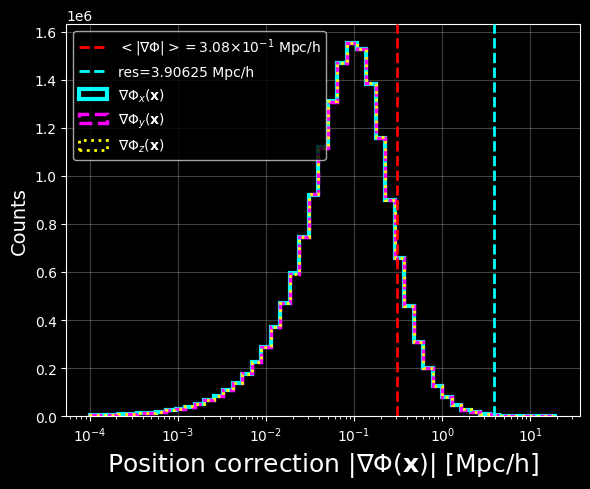

In [132]:
mean_disp = np.mean(np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ))
max_disp = np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ).max()
print(mean_disp)
print(max_disp)
print(grad_x_real.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(grad_x_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax.hist(np.abs(grad_y_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax.hist(np.abs(grad_z_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

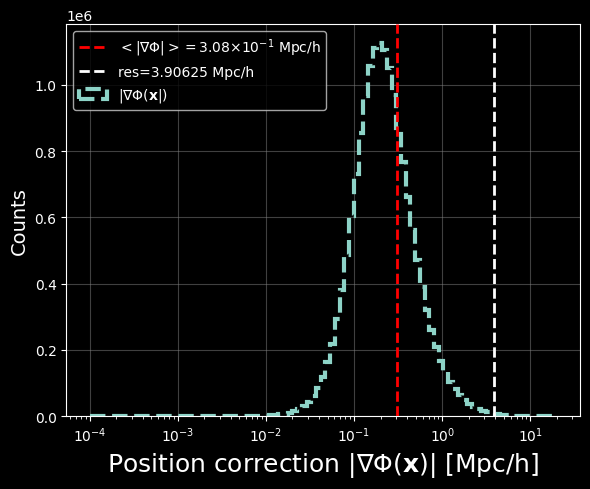

In [134]:
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 100)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "white", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ).flatten(),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$|\nabla \Phi(\mathbf{x}|)$", cumulative=cumhist, linestyle = "dashed" , lw = 3)
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

In [135]:
# threshold = 1.0*BoxSize/grid #voxel size
# grad_x_real[np.abs(grad_x_real)>threshold]=0.
# grad_y_real[np.abs(grad_y_real)>threshold]=0.
# grad_z_real[np.abs(grad_z_real)>threshold]=0.

# For the comoving interpolation vector, compute the grid coordinates and then the center of voxels
cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
print(length_grid.min(), length_grid.max())
comoving_length = length_grid + cell/2
print(comoving_length.min(), comoving_length.max())

0.0 996.09375
1.953125 998.046875


In [136]:
pos_disp_nn = np.empty(pos_pm.shape).astype(prec_in) # numpy.modulus throws a tantrum in numba nopython if the types dont match

start = time.time()
pos_disp_nn = displace_positions_nn(pos_pm, pos_disp_nn, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length, BoxSize)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for nn displacemtn"%elapsed)

102.82 seconds of computation for nn displacemtn


In [137]:
print(pos_disp_nn.nbytes/(1024**2), "Mb")
print(pos_disp_nn.dtype)
print(pos_disp_nn.max())
print(pos_disp_nn.min())

3072.0 Mb
complex64
(1000+0j)
0j


In [138]:
pos_disp_interp = np.empty(pos_pm.shape).astype(prec_in)

start = time.time()
pos_disp_interp = displace_positions_interp(pos_pm, pos_disp_interp, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length, comoving_length, comoving_length, BoxSize)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for interp displacement"%elapsed)

35.28 seconds of computation for interp displacement


In [80]:
print(pos_disp_interp.nbytes/(1024**2), "Mb")
print(pos_disp_interp.dtype)
print(pos_disp_interp.max())
print(pos_disp_interp.min())

3072.0 Mb
complex64
(1000+0j)
0j


In [41]:
print(np.mean(pos_disp_nn - pos_pm))
print(np.mean(pos_disp_interp - pos_pm))
#del pos_pm

(-0.01467343+0j)
(0.018210368+0j)


### Examine power spectrum of displaced particles

In [81]:
# N-body (=target if no emulator)
delta_disp_nn = get_delta(pos=pos_disp_nn.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_disp_nn, Pk_disp_nn, _, _ = compute_Pk(delta_disp_nn, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

/tmp/ipykernel_3345233/2472363182.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  delta_disp_nn = get_delta(pos=pos_disp_nn.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)



Using CIC mass assignment scheme
Time taken = 1.806 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds


In [82]:
delta_disp_interp = get_delta(pos=pos_disp_interp.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_disp_interp, Pk_disp_interp, _, _ = compute_Pk(delta_disp_interp, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

/tmp/ipykernel_3345233/1301326780.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  delta_disp_interp = get_delta(pos=pos_disp_interp.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)



Using CIC mass assignment scheme
Time taken = 1.824 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds


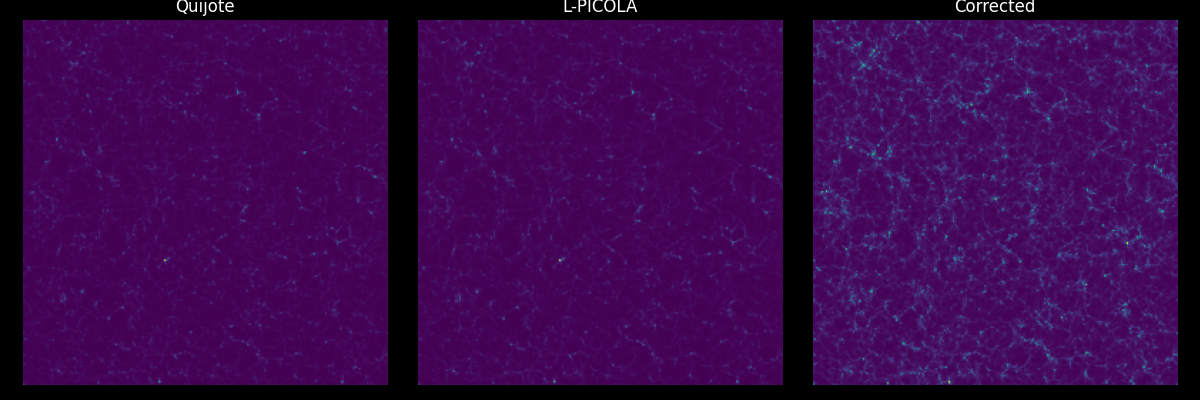

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# plt.imshow(delta[0])
ind=50
axes[0].imshow(delta_nb[ind])
axes[0].set_title("Quijote")

axes[1].imshow(delta_pm[ind])
axes[1].set_title("L-PICOLA")


axes[2].imshow(delta_disp_interp[ind])
axes[2].set_title("Corrected")
# axes[2].imshow(delta_disp_interp[ind])
# axes[2].set_title("Corrected")

for ax in axes:
    ax.axis("off")

plt.tight_layout()  # Adjust layout
plt.show()
plt.savefig(os.path.join(fig_fold, "corrected_slices.pdf"), bbox_inches = "tight")

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

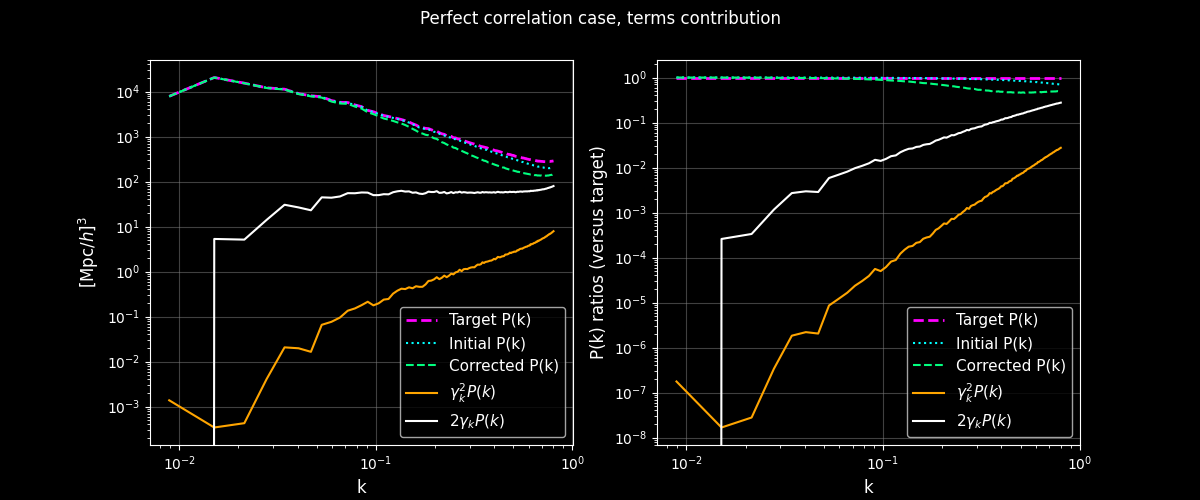

In [46]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k, Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, Pk_disp_interp[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_target[inds]/Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_target[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, Pk_disp_interp[inds]/Pk_target[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_target[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_target[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

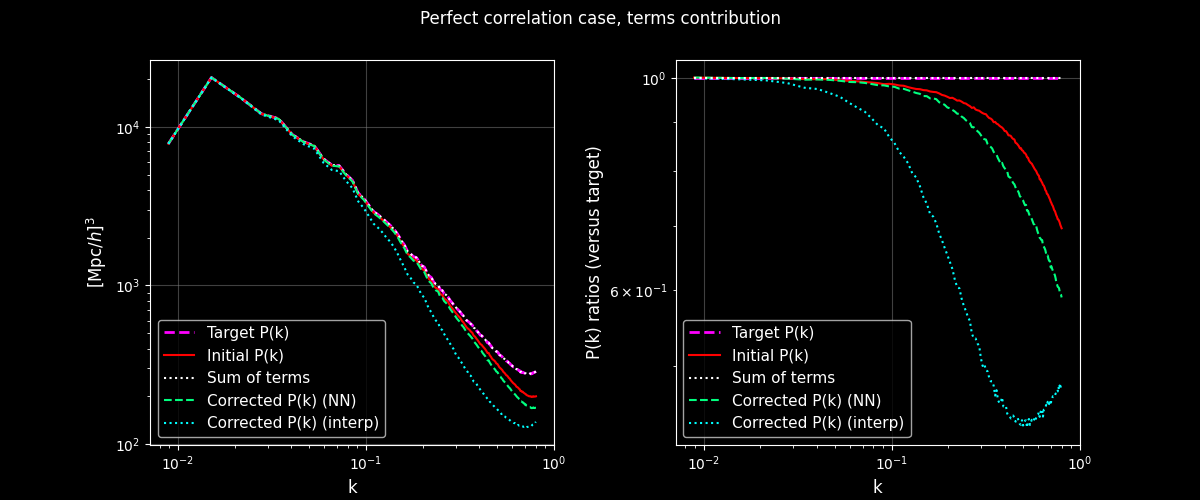

In [84]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

summ_th =  coeffs[:,0]*(roots[:,1].real)**2+coeffs[:,1]*roots[:,1].real+ Pk_pm[inds]

ax1.plot(k, Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
ax1.plot(k, summ_th, color = "white", lw = 1.5, label = "Sum of terms", ls = "dotted", zorder = 5)
ax1.plot(k, Pk_disp_nn[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k) (NN)", ls = "dashed", zorder = 5)
ax1.plot(k, Pk_disp_interp[inds], color = "aqua", lw = 1.5, label = "Corrected P(k) (interp)", ls = "dotted", zorder = 6)
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_target[inds]/Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_target[inds], color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
ax2.plot(k, summ_th/Pk_target[inds], color = "white", lw = 1.5, label = "Sum of terms", ls = "dotted", zorder = 10)
ax2.plot(k, Pk_disp_nn[inds]/Pk_target[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k) (NN)", ls = "dashed", zorder = 5)
ax2.plot(k, Pk_disp_interp[inds]/Pk_target[inds], color = "aqua", lw = 1.5, label = "Corrected P(k) (interp)", ls = "dotted", zorder = 6)
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)
plt.subplots_adjust(wspace = 0.3)
plt.savefig(os.path.join(fig_fold, "Pk_disp_comparisons.pdf"), bbox_inches = "tight")
plt.suptitle("Perfect correlation case, terms contribution")


Computing power spectra of the fields...
Time FFTS = 0.60
Time loop = 0.36
Time taken = 0.96 seconds

Computing power spectra of the fields...
Time FFTS = 0.56
Time loop = 0.37
Time taken = 0.93 seconds


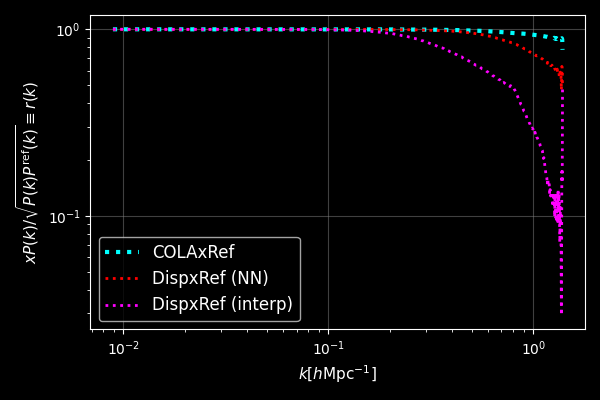

In [48]:
# Cross-Spectrum
k_Xd_nn, Pk_Xd_nn, _, _ = compute_XPk(delta_disp_nn, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rkd_nn= Pk_Xd_nn/np.sqrt(Pk_disp_nn*Pk_nb)
k_Xd_interp, Pk_Xd_interp, _, _ = compute_XPk(delta_disp_interp, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rkd_interp= Pk_Xd_interp/np.sqrt(Pk_disp_interp*Pk_nb)

fig, axes = plt.subplots(1,1, figsize = (6,4))
axes.plot(k_X, rk, ':', label='COLAxRef', zorder= 10, lw = 3, color = "cyan")
axes.plot(k_Xd_nn, rkd_nn, ':', label='DispxRef (NN)', zorder= 10, lw = 2, color = "red")
axes.plot(k_Xd_interp, rkd_interp, ':', label='DispxRef (interp)', zorder= 10, lw = 2, color = "magenta")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.savefig(os.path.join(fig_fold, "Pk_disp_crosscorr.pdf"), bbox_inches = "tight")
plt.tight_layout()

## 2-2) Partial correlation case
\begin{equation}
    \phi (k) = \frac{\gamma_k}{k^2} F_k
\end{equation}
where
\begin{equation}
    \langle F_k \Delta_{k^\prime}^\ast \rangle = r(k) \sqrt{P_\Delta(k) \times P_{F} (k)} \delta^{\rm D} (\vec{k} - \vec{k}^\prime)
\end{equation}
Choose e.g. $F$ to be the mass-weighted density field

**This is only relevant in the halo case.** :)

## 2-3) Uncorrelated case
\begin{equation}
    Q(k) = \frac{\beta_k^2}{k^4} P(k),
\end{equation}
where $\beta \geq 0$.

# 3) Halo test case
Use same data as Anirban's previous example

## Halo Tests from Anirban
number density perspective only

In [139]:
from funcs import *
import scipy
import h5py, itertools
from scipy.fft import *
from nbodykit.lab import *

In [140]:
lhid=0
grid = 256
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/128])
MAS='CIC'
MAS_index=2
kN = np.pi *grid/BoxSize

pos_target = h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# Approx sim
# Either: Fastpm
# pos = h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype(np.float32)
# pos=pos-0.5*BoxSize/128.
# Or: Quijote nbody pos-> NGP
ngp_res = 128
pos = h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos = NGP(pos, ngp_res, BoxSize)

np.random.seed(0)
# Choose your noising scheme
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)/4
# Lnoise = (1000/128)/np.sqrt(3)  # Set by CHARM resolution
# pos += np.random.randn(*pos.shape) * Lnoise
# pos=high_res_pos(pos, n=2)

acc = pos_target-pos
pos = pos%BoxSize
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X, Pk_X, _, _ = compute_XPk(delta, delta_target, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk = Pk_X/np.sqrt(Pk0*Pk0_target)


Using CIC mass assignment scheme
Time taken = 0.037 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Using CIC mass assignment scheme
Time taken = 0.036 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds

Computing power spectra of the fields...
Time FFTS = 0.57
Time loop = 0.36
Time taken = 0.93 seconds


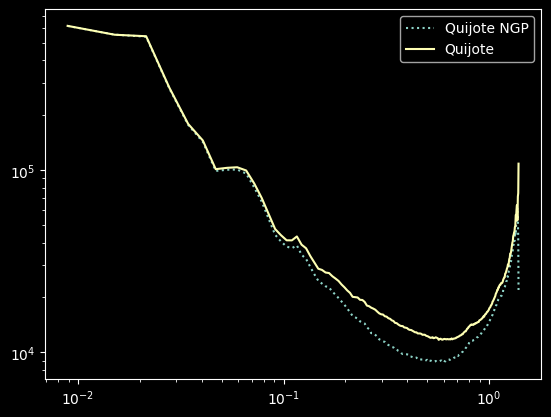

In [141]:
plt.figure()
plt.plot(k, Pk0, ':', label='Quijote NGP')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.loglog()
plt.legend()

Text(0, 0.5, '$r(k)$')

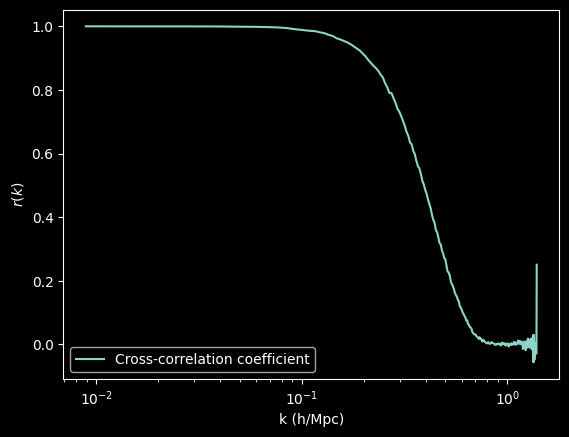

In [142]:
plt.figure()
plt.plot(k_X, rk, label='Cross-correlation coefficient')
plt.semilogx()
plt.legend()
plt.xlabel("k (h/Mpc)")
plt.ylabel("$r(k)$")

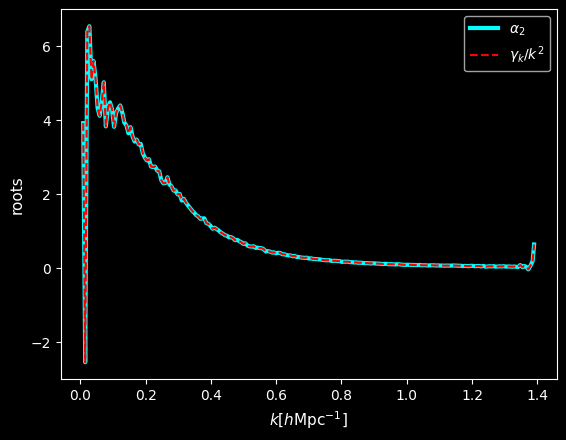

In [143]:
# Choose you configuration for root finding : 
# get_roots-> number density, get_roots_overdensity-> Overdensity
# TODO: Create a class for various configuration

# With beta cnovention
roots, coeffs=get_roots(k, Pk0, Pk0_target, BoxSize)
#roots, coeffs=get_roots_overdensity(k, Pk0, Pk0_target, rk, BoxSize=1000.)

# With gamma convention
roots_g, coeffs_g=get_roots_gamma(k, Pk0, Pk0_target)

fig = plt.figure()
plt.plot(k,roots[:,1].real, label=r'$\alpha_2 $', color = "cyan", lw = 3)
plt.plot(k, roots_g[:,1].real/k**2, label = r"$\gamma_k/k^2$", ls = "--", zorder =3, color = "red")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
plt.ylabel(r"roots", fontsize = 11)
# plt.loglog()
plt.legend()

In [144]:
print(k[3]-k[2])
print(2*np.pi/BoxSize)

0.0063887059003244
0.006283185307179587


In [145]:
freq = np.fft.fftshift(np.fft.fftfreq(grid, BoxSize/grid))
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*2*np.pi
print(rad.min(), rad.max())

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(np.pi * BoxSize * fx / grid, MAS_index)
MAS_factor_ky = MAS_correction(np.pi * BoxSize * fy / grid, MAS_index)
MAS_factor_kz = MAS_correction(np.pi * BoxSize * fz / grid, MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# int(0.5*grid*np.sqrt(3)) --> Is this straight out of Pylians ?
binlist = np.linspace(rad.min(), rad.max(), int(0.5*grid*np.sqrt(3)))
index = np.digitize(rad, binlist)-1
print(index.shape, rad.min(), rad.max())

# numpy.digitize(x, bins, right=False)
# Return the indices of the bins to which each value in input array x belongs.

# x = np.array([0.2, 6.4, 3.0, 1.6])
# bins = np.array([0.0, 1.0, 2.5, 4.0, 10.0])
# inds = np.digitize(x, bins)
# inds
# >>>>array([1, 4, 3, 2])

# Choose between number density and overdensity
delta_k = np.fft.fftshift(np.fft.fftn(delta)) # no mass weighting

# MAS or no MASS correction ?
delta_k_nomas = delta_k.copy()
delta_k=np.multiply(MAS_factor,delta_k)
            
# Choose correct multiplication factor for number density vs overdensity
print(roots[:,1].shape)
weights = roots[:,1].real[:int(0.5*grid*np.sqrt(3))] 
print(weights.shape)

phi_k = weights[index]*delta_k
phi_knomas = weights[index]*delta_k_nomas

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=BoxSize/ngp_res)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_knomas, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=BoxSize/ngp_res)

delta_correctednomas=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_correctednomas, Pk0_correctednomas, _, _ = compute_Pk(delta_correctednomas, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

0.0 1.3929979117318794
(256, 256, 256) 0.0 1.3929979117318794
(221,)
(221,)
[-0.-0.80424772j -0.-0.67858401j -0.-0.55292031j -0.-0.4272566j
 -0.-0.30159289j -0.-0.17592919j -0.-0.05026548j  0.+0.07539822j
  0.+0.20106193j  0.+0.32672564j  0.+0.45238934j  0.+0.57805305j
  0.+0.70371675j]

Using CIC mass assignment scheme
Time taken = 0.039 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds
[-0.-0.80424772j -0.-0.67858401j -0.-0.55292031j -0.-0.4272566j
 -0.-0.30159289j -0.-0.17592919j -0.-0.05026548j  0.+0.07539822j
  0.+0.20106193j  0.+0.32672564j  0.+0.45238934j  0.+0.57805305j
  0.+0.70371675j]

Using CIC mass assignment scheme
Time taken = 0.038 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds


In [152]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# Choose between number density and overdensity
delta_k = np.fft.fftshift(np.fft.fftn(delta)) # no mass weighting

delta_k = np.multiply(MAS_factor,delta_k)

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

weights1D = roots_g[:,1].real/(k**2)
# Put gamma_k weights in 3D
print(k.max())
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, rad , k, weights1D)

# Finally compute Phi_k
phi_k_alt = weights_grid* delta_k

a_x_alt, a_y_alt, a_z_alt = calculate_acc_from_phi_k(phi_k_alt, grid=grid, BoxSize=BoxSize)
pos_corrected_alt = correct_pos(pos, a_x_alt, a_y_alt, a_z_alt, grid=grid, BoxSize=BoxSize, threshold=1000./128)
print(a_x_alt.max())

delta_corrected_alt=get_delta(pos=pos_corrected_alt, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected_alt, Pk0_corrected_alt, _, _ = compute_Pk(delta_corrected_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

0.0 1.3929979117318794
1.3902843163141774
[-0.-0.80424772j -0.-0.67858401j -0.-0.55292031j -0.-0.4272566j
 -0.-0.30159289j -0.-0.17592919j -0.-0.05026548j  0.+0.07539822j
  0.+0.20106193j  0.+0.32672564j  0.+0.45238934j  0.+0.57805305j
  0.+0.70371675j]
51.66206932709471

Using CIC mass assignment scheme
Time taken = 0.036 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds


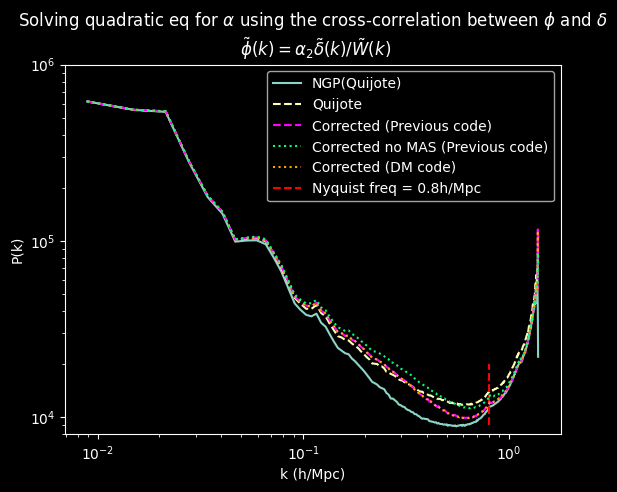

In [147]:
plt.figure()
plt.plot(k, Pk0, label='NGP(Quijote)') #'Quijote halos perturbed \n uniformly from the center of the voxel')
plt.plot(k_target, Pk0_target, '--', label='Quijote')# Nbody')
plt.plot(k_corrected, Pk0_corrected, ls='--', label='Corrected (Previous code)', color = "magenta", zorder = 4)
plt.plot(k_correctednomas, Pk0_correctednomas, label='Corrected no MAS (Previous code)', color = "springgreen", zorder = 5, ls = "dotted")
plt.plot(k_corrected_alt, Pk0_corrected_alt, ls=':', label='Corrected (DM code)', color = "orange", zorder = 4)
plt.vlines(np.pi*grid/BoxSize, 9e3, 2e4, color='r',ls='--', label='Nyquist freq = 0.8h/Mpc')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([8e3,1e6])
plt.legend()

## Debugging sections

### Acceleration in real space

In [148]:
# From Anirban's funcs.py
a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)

[-0.-0.80424772j -0.-0.67858401j -0.-0.55292031j -0.-0.4272566j
 -0.-0.30159289j -0.-0.17592919j -0.-0.05026548j  0.+0.07539822j
  0.+0.20106193j  0.+0.32672564j  0.+0.45238934j  0.+0.57805305j
  0.+0.70371675j]


In [149]:
# My attempt
fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
kx_g, ky_g, kz_g = np.meshgrid(kx_v, ky_v, kz_v, indexing = "ij")

scale = 2*np.pi*grid/BoxSize # k sampling rate
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32") # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')
print((kx_g==fx).all()) # false if no dtype float32
print((kx_g-fx).max())

grad_x_fourier = -1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier = -1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier = -1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

grad_x_fourier_g = -1.0j*fx * phi_k
grad_y_fourier_g = -1.0j*fy * phi_k
grad_z_fourier_g = -1.0j*fz * phi_k

# The two computations should be exactly the same
print((grad_x_fourier == grad_x_fourier_g).all())
print((grad_y_fourier == grad_y_fourier_g).all())
print((grad_z_fourier == grad_z_fourier_g).all())

True
0.0
True
True
True


In [150]:
# Initialize
start = time.time()
N_CPU = 16


prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)


fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)


grad_x_real = fftw_planx(arr_inx, arr_outx)
grad_y_real = fftw_plany(arr_iny, arr_outy)
grad_z_real = fftw_planz(arr_inz, arr_outz)
end=time.time()
print("Computation: %.3f seconds"%(end-start))
print(grad_x_real.dtype)

Computation: 0.542 seconds
complex64


Text(0.5, 1.0, 'With DM code')

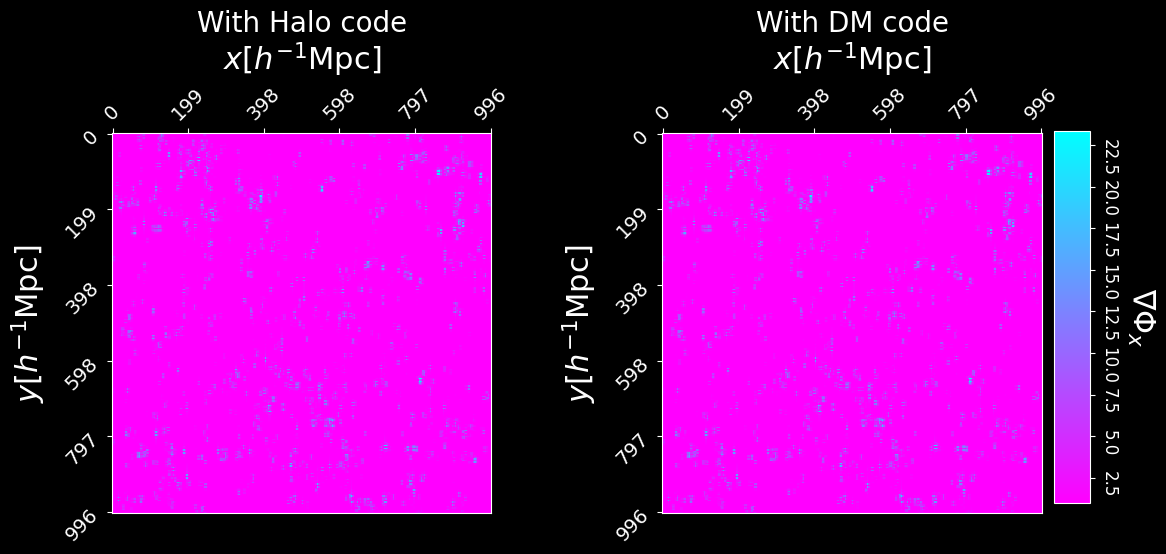

In [151]:
cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)

fig, axes = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 2, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] 

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"


logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = len(length_grid)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(a_x[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax = abs(a_x[:,:,indcut]).max()))
    im2 = ax2.matshow(abs(grad_x_real[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(grad_x_real[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(a_x[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(a_x[:,:,indcut]).max())
    im2 = ax2.matshow(abs(grad_x_real[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(grad_x_real[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\nabla \Phi_x$" , fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.0f}".format(x)
labelX = np.linspace(0, length_grid.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$x [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$y [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelX)
ax1.set_yticks(labelX)
ax1.set_xticklabels([fmtM(j) for j in length_grid[labelX]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in length_grid[labelX]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
ax1.set_title("With Halo code", fontsize = 20)


ax2.set_xlabel(r"$x [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$y [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelX)
ax2.set_yticks(labelX)
ax2.set_xticklabels([fmtM(j) for j in length_grid[labelX]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in length_grid[labelX]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)
ax2.set_title("With DM code", fontsize = 20)

### Accelaration interpolation
$x^{'} = x + \nabla \Phi $

In [153]:
a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)

[-0.-0.80424772j -0.-0.67858401j -0.-0.55292031j -0.-0.4272566j
 -0.-0.30159289j -0.-0.17592919j -0.-0.05026548j  0.+0.07539822j
  0.+0.20106193j  0.+0.32672564j  0.+0.45238934j  0.+0.57805305j
  0.+0.70371675j]


In [163]:
grid_pos = pos*grid/BoxSize #- 0.5
acc = np.moveaxis(np.array([a_x, a_y, a_z]),0,-1) #= a_x*grid/BoxSize, a_y*grid/BoxSize, a_z*grid/BoxSize
print(acc.shape)
acc_at_particles = np.zeros_like(pos)

i0 = np.floor(grid_pos).astype(int)%grid  # Base index per particle
d = grid_pos - i0  # Fractional offset in cell

for shift in np.ndindex(2, 2, 2):  # Loop over 8 corners
    w = (
        (1 - d[:, 0]) if shift[0] == 0 else d[:, 0]
    ) * (
        (1 - d[:, 1]) if shift[1] == 0 else d[:, 1]
    ) * (
        (1 - d[:, 2]) if shift[2] == 0 else d[:, 2]
    )

    # Get indices with shift, apply periodic boundary conditions
    ix = (i0[:, 0] + shift[0]) % grid
    iy = (i0[:, 1] + shift[1]) % grid
    iz = (i0[:, 2] + shift[2]) % grid
    
    acc_at_particles += w[:, None]*acc[ix, iy, iz]
print(acc_at_particles.shape)

(256, 256, 256, 3)
(122313, 3)


In [155]:
# For the comoving interpolation vector, compute the grid coordinates and then the center of voxels
cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
print(length_grid.min(), length_grid.max())
comoving_length = length_grid + cell/2
print(comoving_length.min(), comoving_length.max())

0.0 996.09375
1.953125 998.046875


In [164]:
nabla_x = trilinear_interp_numba(a_x, pos,comoving_length, comoving_length, comoving_length) #"c" for comoving coordinates
nabla_y = trilinear_interp_numba(a_y, pos,comoving_length, comoving_length, comoving_length)
nabla_z = trilinear_interp_numba(a_z, pos, comoving_length, comoving_length, comoving_length)
print(nabla_x.shape)

(122313,)


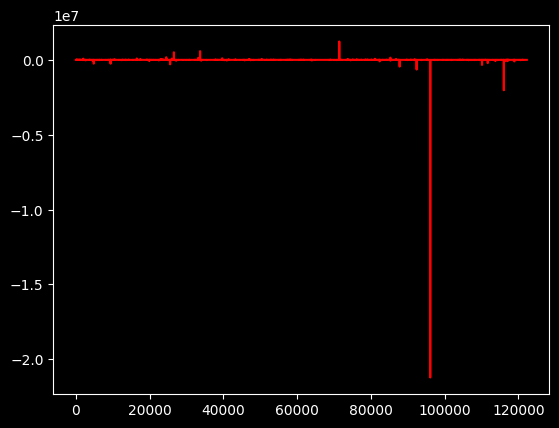

In [171]:
plt.figure()
plt.plot(nabla_x/acc_at_particles[:,0], color = "red")
#plt.plot(nabla_x, color ="cyan", ls = "--" )

In [158]:
pos_disp_interp = np.empty(pos.shape).astype(prec_in)

start = time.time()
pos_disp_interp = displace_positions_interp(pos.astype(prec_in), pos_disp_interp, grad_x_real.astype(prec_in), grad_y_real.astype(prec_in), 
                              grad_z_real.astype(prec_in), comoving_length, comoving_length, comoving_length, BoxSize)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for interp displacement"%elapsed)

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<function searchsorted at 0x14f1d80d1b40>) found for signature:
 
 >>> searchsorted(array(float64, 1d, C), complex64, side=Literal[str](left))
 
There are 2 candidate implementations:
    - Of which 1 did not match due to:
    Overload in function 'searchsorted': File: numba/np/arraymath.py: Line 3811.
      With argument(s): '(array(float64, 1d, C), complex64, side=unicode_type)':
     Rejected as the implementation raised a specific error:
       NumbaValueError: Invalid value given for 'side': unicode_type
  raised from /home/x-nchartier/miniconda3/envs/pkcorr/lib/python3.10/site-packages/numba/np/arraymath.py:3818
    - Of which 1 did not match due to:
    Overload in function 'searchsorted': File: numba/np/arraymath.py: Line 3811.
      With argument(s): '(array(float64, 1d, C), complex64, side=Literal[str](left))

### $\Delta_k$ weighting
CAREFUL: the roots alpha or gamma are calculated until the Pylians limit $k_N*\sqrt{3}$, and not my vectors from fourier_shell_grid

In [65]:
freq = np.fft.fftshift(np.fft.fftfreq(grid, BoxSize/grid))
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

# Compute radial distances
rad =np.sqrt(fx**2 + fy**2 + fz**2)* 2*np.pi

# int(0.5*grid*np.sqrt(3)) --> Is this straight out of Pylians ?
binlist = np.linspace(rad.min(), rad.max(), int(0.5*grid*np.sqrt(3)))
index = np.digitize(rad, binlist)-1
print(index.shape, rad.min(), rad.max())
print(k.min(), k.max(), kN*np.sqrt(3))
print(binlist.max())

# Choose between number density and overdensity
delta_k = np.fft.fftshift(np.fft.fftn(delta)) # no mass weighting

# MAS or no MASS correction ?
delta_k_nomas = delta_k.copy()
delta_k=np.multiply(MAS_factor,delta_k)
            
# Choose correct multiplication factor for number density vs overdensity
print(roots[:,1].shape)
weights = roots[:,1].real[:int(0.5*grid*np.sqrt(3))] 
#weights = roots[:,1].real[:int(0.5*grid*np.sqrt(3))] *np.sqrt(Pk0/Pk0_m)
print(weights.shape)

phi_k = weights[index]*delta_k

(256, 256, 256) 0.0 1.3929979117318794
0.008899641224696954 1.3902843163141774 1.3929979117318794
1.3929979117318794
(221,)
(221,)


In [66]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale

weights1D = roots_g[:,1].real/(k**2)
# Put gamma_k weights in 3D
print(k.max())
print(rad.max())
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, rad , k, weights1D)

phi_k_alt = weights_grid*delta_k

1.3902843163141774
1.3929979117318794


1.382115115546474
(83,)
(256,)


Text(0.5, 1.0, 'With DM code (interpolation)')

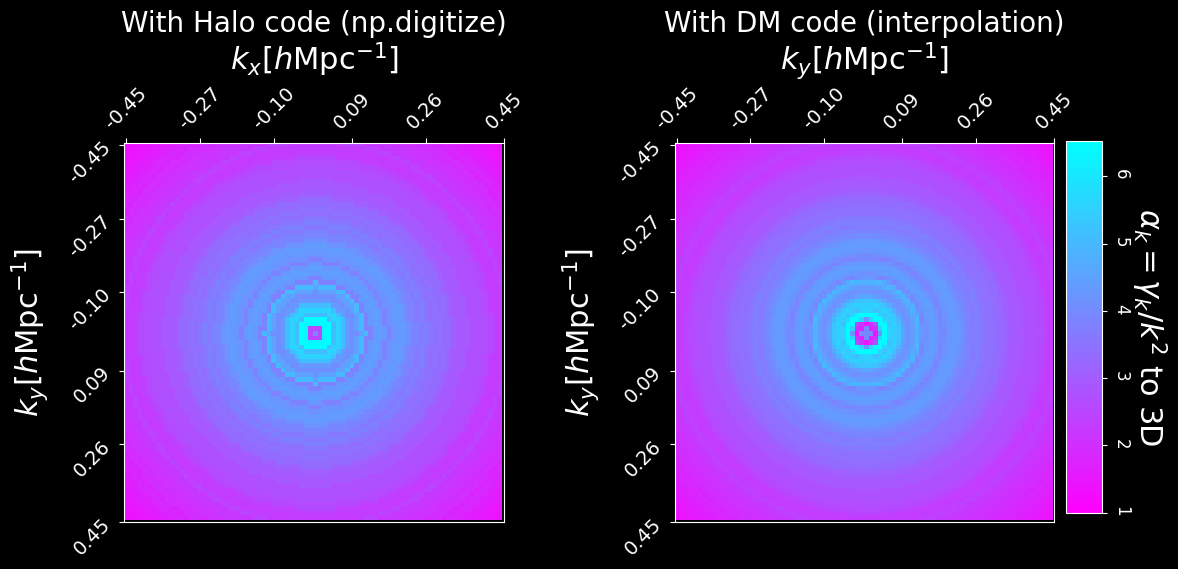

In [67]:
fig, axes = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 2, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] 

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -0.45
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(weights[index][indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax = abs(weights[index][:,:,indcut]).max()))
    im2 = ax2.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(weights_grid[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(weights[index][indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(weights[index][:,:,indcut]).max())
    im2 = ax2.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(weights_grid[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\alpha_k = \gamma_k/k^2$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
ax1.set_title("With Halo code (np.digitize)", fontsize = 20)

ax2.set_xlabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kpl[indp][labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)
ax2.set_title("With DM code (interpolation)", fontsize = 20)

1.382115115546474
(83,)
(256,)


Text(0.5, 1.0, 'With DM code (interpolation)')

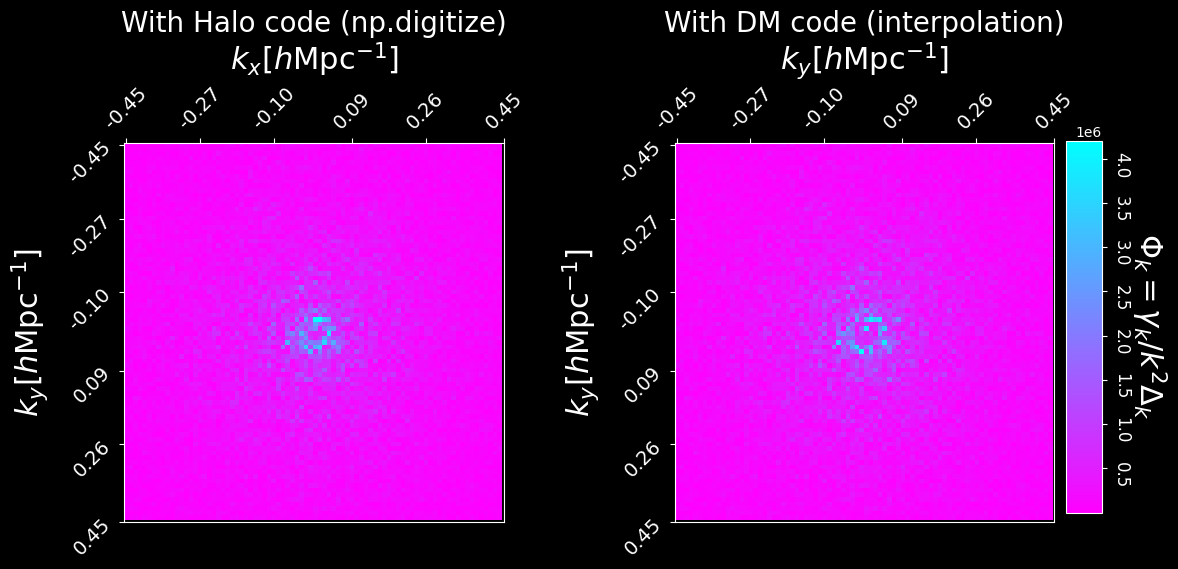

In [73]:
fig, axes = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 2, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] 

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -0.45
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(phi_k[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax = abs(phi_k[:,:,indcut]).max()))
    im2 = ax2.matshow(abs(phi_k_alt[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(phi_k_alt[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(phi_k[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(phi_k[:,:,indcut]).max())
    im2 = ax2.matshow(abs(phi_k_alt[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(phi_k_alt[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\Phi_k = \gamma_k/k^2 \Delta_k$", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
ax1.set_title("With Halo code (np.digitize)", fontsize = 20)

ax2.set_xlabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kpl[indp][labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)
ax2.set_title("With DM code (interpolation)", fontsize = 20)

### MAS

In [46]:
kN = np.pi *grid/BoxSize

# Arnirban frequency array
freq = np.fft.fftshift(np.fft.fftfreq(grid, d=BoxSize/grid))  # second argument is sample spacing L_s, inverse of sampling rate 1/L_s=F_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')
print("Anirban freq array: ",2*np.pi*freq[::10], "\n") # same as my freq array at the bottom
print("Anirban x array for MAS(x), ", np.pi * BoxSize * freq[::10] / grid, "\n") # in Anirban code

# My frequency array ; nu = f/f_s = reduced frequency
freqa = np.fft.fftshift(np.fft.fftfreq(grid))
fxa, fya, fza = np.meshgrid(freqa, freqa, freqa, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k "resolution" and Nyquist wavenumber is half of that
# freq_alt = np.array(scale*np.fft.fftshift(np.fft.fftfreq(grid)), dtype='float32')
print("My freq array, ", scale*freqa[::10], "\n")
print("My x array for MAS(x)",scale*freqa[::10] * np.pi/2.*1./kN , "\n")

print("k Nyquist: ", kN, "\n")
print("k max Pylians", k_target.max())

Anirban freq array:  [-0.80424772 -0.74141587 -0.67858401 -0.61575216 -0.55292031 -0.49008845
 -0.4272566  -0.36442475 -0.30159289 -0.23876104 -0.17592919 -0.11309734
 -0.05026548  0.01256637  0.07539822  0.13823008  0.20106193  0.26389378
  0.32672564  0.38955749  0.45238934  0.5152212   0.57805305  0.6408849
  0.70371675  0.76654861] 

Anirban x array for MAS(x),  [-1.57079633 -1.44807786 -1.3253594  -1.20264094 -1.07992247 -0.95720401
 -0.83448555 -0.71176709 -0.58904862 -0.46633016 -0.3436117  -0.22089323
 -0.09817477  0.02454369  0.14726216  0.26998062  0.39269908  0.51541754
  0.63813601  0.76085447  0.88357293  1.0062914   1.12900986  1.25172832
  1.37444679  1.49716525] 

My freq array,  [-0.80424772 -0.74141587 -0.67858401 -0.61575216 -0.55292031 -0.49008845
 -0.4272566  -0.36442475 -0.30159289 -0.23876104 -0.17592919 -0.11309734
 -0.05026548  0.01256637  0.07539822  0.13823008  0.20106193  0.26389378
  0.32672564  0.38955749  0.45238934  0.5152212   0.57805305  0.6408849
  0.

$W_n(k) = \left[ \mathrm{sinc}(\frac{\pi}{2}\frac{k}{k_N}) \right]$

$k_N = \frac{\pi}{\Delta_x} = \frac{\pi N}{L}$

In [47]:
dims =grid
middle = grid//2
prefact = np.pi/dims

MAS_corr_pl = np.empty((grid, grid, grid))
i=0
for kxx in range(dims):
    kx = (kxx-dims if (kxx>middle) else kxx)
    MAS_x = MAS_corr_pylians(prefact*kx,MAS_index)

    j=0
    for kyy in range(dims):
        ky = (kyy-dims if (kyy>middle) else kyy)
        MAS_y = MAS_corr_pylians(prefact*ky,MAS_index)

        l=0
        for kzz in range(dims): #kzz=[0,1,..,middle] --> kz>0
            kz = (kzz-dims if (kzz>middle) else kzz)
            MAS_z = MAS_corr_pylians(prefact*kz,MAS_index)  

            MAS_corr_pl[i,j,l] =MAS_x*MAS_y*MAS_z
            l+=1
        j+=1
    i+=1
print(MAS_corr_pl.min(), MAS_corr_pl.max())
MAS_corr_pl = np.fft.fftshift(MAS_corr_pl, axes = (0,1,2))

1.0 15.021706149614129


In [48]:
scale = 2*np.pi*grid/BoxSize
print(np.fft.fftshift(np.fft.fftfreq(grid))[::10]) # nu = f/f_s = reduced frequency
print(np.fft.fftshift(np.fft.fftfreq(grid))[::10]*scale)

[-0.5       -0.4609375 -0.421875  -0.3828125 -0.34375   -0.3046875
 -0.265625  -0.2265625 -0.1875    -0.1484375 -0.109375  -0.0703125
 -0.03125    0.0078125  0.046875   0.0859375  0.125      0.1640625
  0.203125   0.2421875  0.28125    0.3203125  0.359375   0.3984375
  0.4375     0.4765625]
[-0.80424772 -0.74141587 -0.67858401 -0.61575216 -0.55292031 -0.49008845
 -0.4272566  -0.36442475 -0.30159289 -0.23876104 -0.17592919 -0.11309734
 -0.05026548  0.01256637  0.07539822  0.13823008  0.20106193  0.26389378
  0.32672564  0.38955749  0.45238934  0.5152212   0.57805305  0.6408849
  0.70371675  0.76654861]


In [49]:
####################################################
####################################################
freq = np.fft.fftshift(np.fft.fftfreq(grid, BoxSize/grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)
print(rad.min(), rad.max())

# Compute MAS correction factors, x is 
MAS_factor_kx = MAS_correction(np.pi * BoxSize * fx / grid, MAS_index)
MAS_factor_ky = MAS_correction(np.pi * BoxSize * fy / grid, MAS_index)
MAS_factor_kz = MAS_correction(np.pi * BoxSize * fz / grid, MAS_index)

MAS_factor_1 = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

####################################################
####################################################
freq = np.fft.fftshift(np.fft.fftfreq(grid)) 
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)
print(rad.min(), rad.max())
# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)

MAS_factor_2 = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

####################################################
####################################################
fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
kx_g, ky_g, kz_g = np.meshgrid(kx_v, ky_v, kz_v, indexing = "ij")
print(k_radius.shape)
print(k_radius.max())
print(kx_v.min(), kx_v.max())

# Compute MAS correction factors - we first need 3d arrays
MAS_factor_kx = MAS_correction(kx_g/kN* np.pi/2., MAS_index)
MAS_factor_ky = MAS_correction(ky_g/kN* np.pi/2, MAS_index)
MAS_factor_kz = MAS_correction(kz_g/kN* np.pi/2, MAS_index)

MAS_factor_3 = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

print(MAS_factor_1.min(), MAS_factor_1.max())
print(MAS_factor_3.min(), MAS_factor_3.max())
####################################################
####################################################

0.0 0.2217025033688163
0.0 0.8660254037844386
(256, 256, 256)
1.392998
-0.80424774 0.7979645
1.0 15.021706149614129
1.0 15.021709


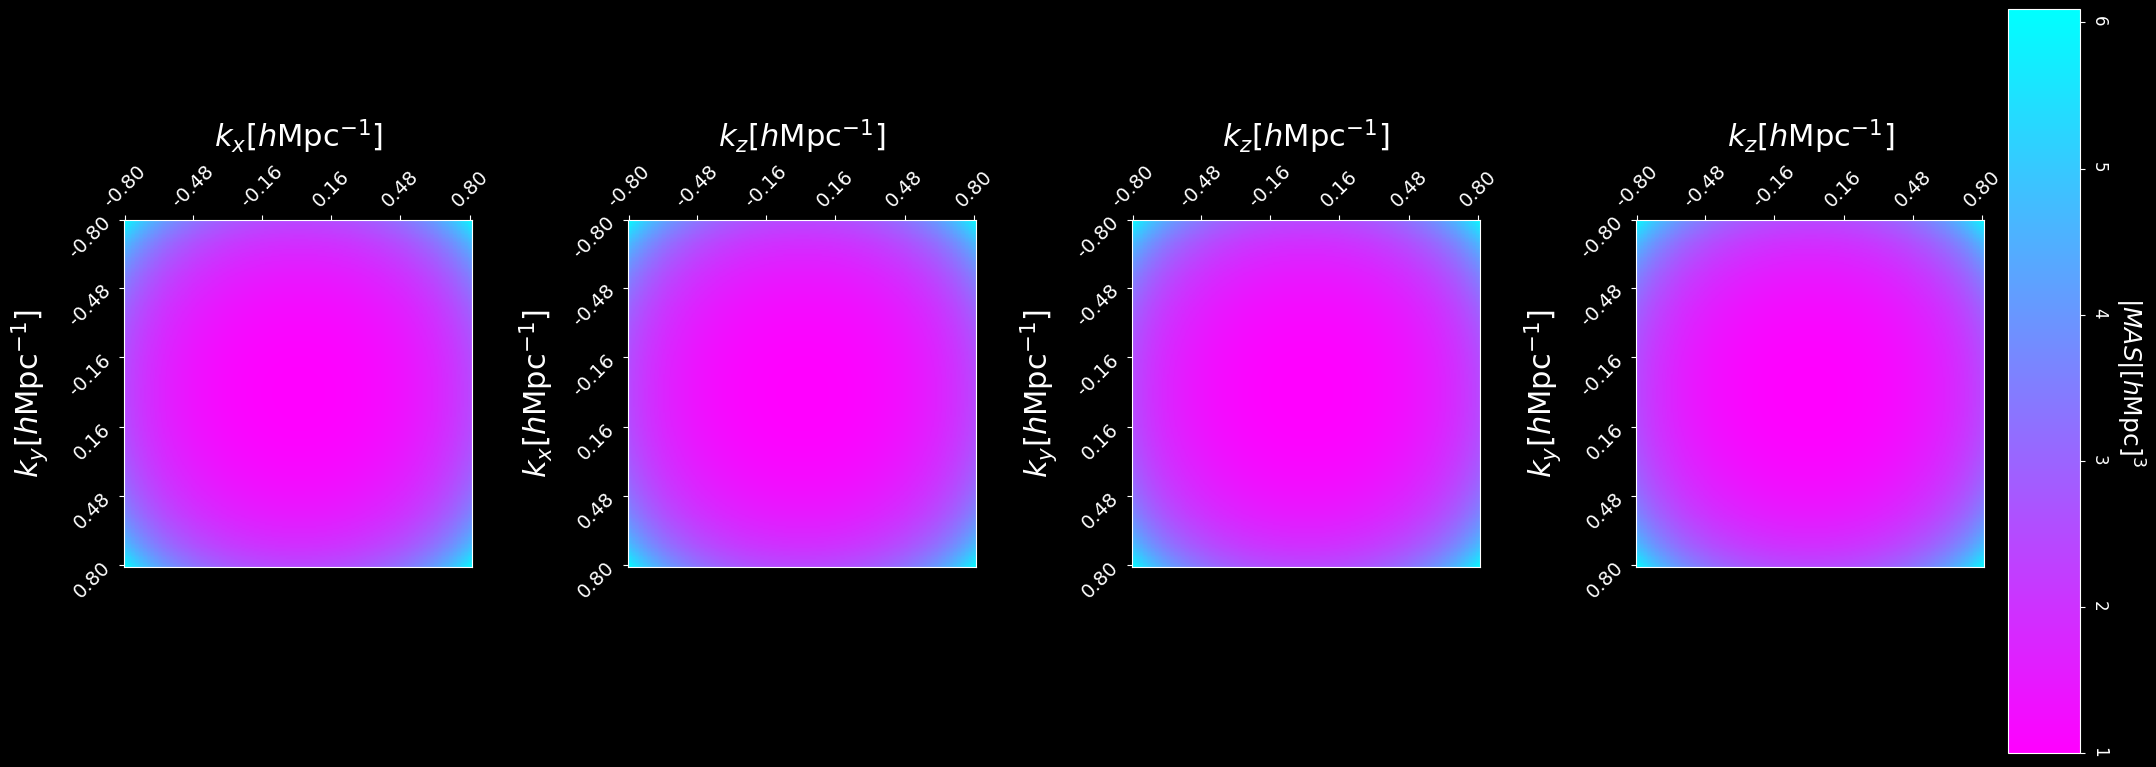

In [53]:
fig, axes = plt.subplots(figsize = (24, 12), nrows = 1, ncols = 4, 
                         sharex = False, sharey = False)
ax1 = axes[0]; ax2 = axes[1] ; ax3 = axes[2]; ax4 = axes[3]

div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

kmip = -0.8
kmap = -kmip

indp = np.where((kx_v>=kmip)&(kx_v<=kmap))[0]
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(MAS_factor_1[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(MAS_factor_1).max()))
    im2 = ax2.matshow(abs(MAS_factor_2[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(MAS_factor_2).max()))
    im3 = ax3.matshow(abs(MAS_factor_3[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(MAS_factor_3).max()))
    im4 = ax4.matshow(abs(MAS_corr_pl[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1, vmax=abs(MAS_corr_pl).max()))
else:
    im1 = ax1.matshow(abs(MAS_factor_1[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(MAS_factor_1[:,:,indcut]).max())
    im2 = ax2.matshow(abs(MAS_factor_2[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(MAS_factor_1[:,:,indcut]).max())
    im3 = ax3.matshow(abs(MAS_factor_3[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(MAS_factor_1[:,:,indcut]).max())
    im4 = ax4.matshow(abs(MAS_corr_pl[:,:,indcut]),cmap = div_cmap, origin = origin, 
                      vmin = 1, vmax = abs(MAS_factor_1[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$|MAS|[h\mathrm{Mpc}]^{3}$", fontsize = 18, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[indp][labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[indp][labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

ax4.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax4.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax4.set_xticks(labelH)
ax4.set_yticks(labelM)
ax4.set_xticklabels([fmtM(j) for j in kz_v[indp][labelH]], rotation = 45, fontsize = 14)
ax4.xaxis.set_ticks_position('top')
ax4.set_yticklabels([fmtM(j) for j in kx_v[indp][labelM]], rotation = 45, fontsize = 14)
ax4.xaxis.set_label_position('top')
ax4.yaxis.set_label_position('left')
ax4.set_box_aspect(1)

## With code for DM

In [26]:
lhid=0
grid = 256
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/128])
MAS='CIC'
MAS_index=2

pos_target = h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

pos = h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos = NGP(pos, 128, BoxSize)

np.random.seed(0)
# Choose your noising scheme
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
acc = pos_target-pos
pos = pos%BoxSize

delta_pm=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X, Pk0_X, _, _ = compute_XPk(delta_target, delta_pm, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk = Pk0_X/np.sqrt(Pk0*Pk0_target)


Using CIC mass assignment scheme
Time taken = 0.036 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds

Using CIC mass assignment scheme
Time taken = 0.035 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Computing power spectra of the fields...
Time FFTS = 0.57
Time loop = 0.37
Time taken = 0.94 seconds


In [27]:
N_CPU = 16
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]

# Initialize
arr_in  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
# Fill data in advance with builders interface
arr_in[:] =  delta_pm.astype(prec_in)
# Instantiate FFTW object
fftw_object = pyfftw.builders.fftn(arr_in,  axes=(0,1,2), threads=N_CPU)
# Compute transform
delta_pm_fourier = fftw_object()

In [28]:
# Keep fftshift True for consistency later on
fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
kx_g, ky_g, kz_g = np.meshgrid(kx_v, ky_v, kz_v, indexing = "ij")
print(k_radius.shape)
print(k_radius.max())
print(kx_v.min(), kx_v.max())

# Compute MAS correction factors - we first need 3d arrays
MAS_factor_kx = MAS_correction(kx_g, MAS_index)
MAS_factor_ky = MAS_correction(ky_g, MAS_index)
MAS_factor_kz = MAS_correction(kz_g, MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz
del MAS_factor_kx, MAS_factor_ky, MAS_factor_kz

(256, 256, 256)
1.392998
-0.80424774 0.7979645


In [52]:
delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
#delta_k = delta_pm_fourier_shift*MAS_factor # "wrong convention"
delta_k = delta_pm_fourier_shift*MAS_factor_1 # with Anirban's freq vectors

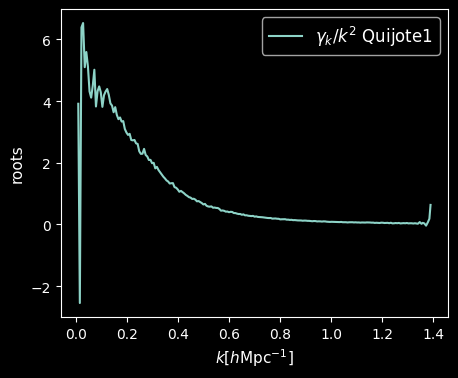

In [53]:
high_roots = True
# With gamma convention
roots_nb, coeffs_nb=get_roots_gamma(k, Pk0, Pk0_target)

# "Positive" roots
gamma_k_nb1 = roots_nb[:,1].real

# "Lower" roots
gamma_k_nb2 = roots_nb[:,0].real

fig, ax = plt.subplots(figsize = (5,4), ncols = 1, nrows= 1)
ax.plot(k, gamma_k_nb1/k**2, label=r'$\gamma_k/k^2$' + " Quijote1")
#ax.plot(k, gamma_k_nb2, label=r'$\gamma_k$' + " Quijote2")
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
ax.set_ylabel(r"roots", fontsize = 11)
#plt.tight_layout()
#plt.savefig(os.path.join(fig_fold, "gammak_roots.pdf"), bbox_inches = "tight")

# Sets the roots for later with the same variable names
gamma_k = gamma_k_nb1 if high_roots else gamma_k_nb2
coeffs = coeffs_nb
roots = roots_nb

In [54]:
print(k.shape == gamma_k.shape)
weights1D = gamma_k/(k**2)

# Put gamma_k weights in 3D
print(k.max())
print(kx_v.max())
print(k_radius.max())
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
# 04/09/2025 -> MAS discrepancy from the debugging part is not even he main culprit here
# (I tested both below, with and without MAS correction for delta)
phi_k = weights_grid* delta_k
#phi_k = weights_grid*delta_pm_fourier_shift

True
1.3902843163141774
0.7979645
1.392998


In [55]:
grad_x_fourier = -1.0j*kx_v[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier = -1.0j*ky_v[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier = -1.0j*kz_v[np.newaxis, np.newaxis, :] * phi_k

grad_x_fourier_g = -1.0j*kx_g * phi_k
grad_y_fourier_g = -1.0j*ky_g * phi_k
grad_z_fourier_g = -1.0j*kz_g * phi_k

# The two computations should be exactly the same
print((grad_x_fourier == grad_x_fourier_g).all())
print((grad_y_fourier == grad_y_fourier_g).all())
print((grad_z_fourier == grad_z_fourier_g).all())

True
True
True


In [56]:
# Initialize
start = time.time()
N_CPU = 16
arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)


fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)


grad_x_real = fftw_planx(arr_inx, arr_outx)
grad_y_real = fftw_plany(arr_iny, arr_outy)
grad_z_real = fftw_planz(arr_inz, arr_outz)
end=time.time()
print("Computation: %.3f seconds"%(end-start))
print(grad_x_real.dtype)

Computation: 0.504 seconds
complex64


In [57]:
grad_x_real = grad_x_real.real
grad_y_real = grad_y_real.real
grad_z_real = grad_z_real.real

1.5507919
57.41914
float32


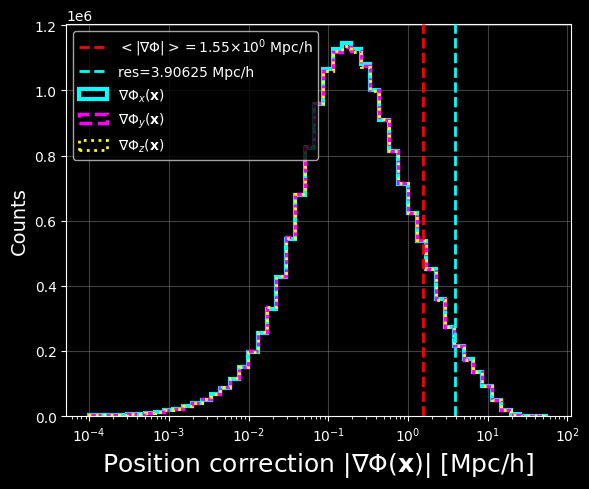

In [58]:
mean_disp = np.mean(np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ))
max_disp = np.sqrt(grad_x_real**2 + grad_y_real**2+grad_z_real**2 ).max()
print(mean_disp)
print(max_disp)
print(grad_x_real.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(grad_x_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax.hist(np.abs(grad_y_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax.hist(np.abs(grad_z_real.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

In [59]:
# For the comoving interpolation vector, compute the grid coordinates and then the center of voxels
cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
print(length_grid.min(), length_grid.max())
comoving_length = length_grid + cell/2
print(comoving_length.min(), comoving_length.max())

pos_halo_nn = np.empty(pos.shape).astype(prec_in) # numpy.modulus throws a tantrum in numba nopython if the types dont match

start = time.time()
pos_disp_nn = displace_positions_nn(pos, pos_halo_nn, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length, BoxSize)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for nn displacemtn"%elapsed)

0.0 996.09375
1.953125 998.046875
0.12 seconds of computation for nn displacemtn


In [60]:
pos_halo_interp = np.empty(pos.shape).astype(prec_in)

start = time.time()
pos_disp_interp = displace_positions_interp(pos, pos_halo_interp, grad_x_real, grad_y_real, 
                              grad_z_real, comoving_length, comoving_length, comoving_length, BoxSize)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation for interp displacement"%elapsed)

0.06 seconds of computation for interp displacement



Using CIC mass assignment scheme
Time taken = 0.037 seconds


Computing power spectrum of the field...


/tmp/ipykernel_2955995/679963495.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  delta_halo_nn = get_delta(pos=pos_halo_nn.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)


Time to complete loop = 0.54
Time taken = 0.81 seconds

Using CIC mass assignment scheme
Time taken = 0.039 seconds


Computing power spectrum of the field...


/tmp/ipykernel_2955995/679963495.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  delta_halo_interp = get_delta(pos=pos_halo_interp.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)


Time to complete loop = 0.54
Time taken = 0.81 seconds


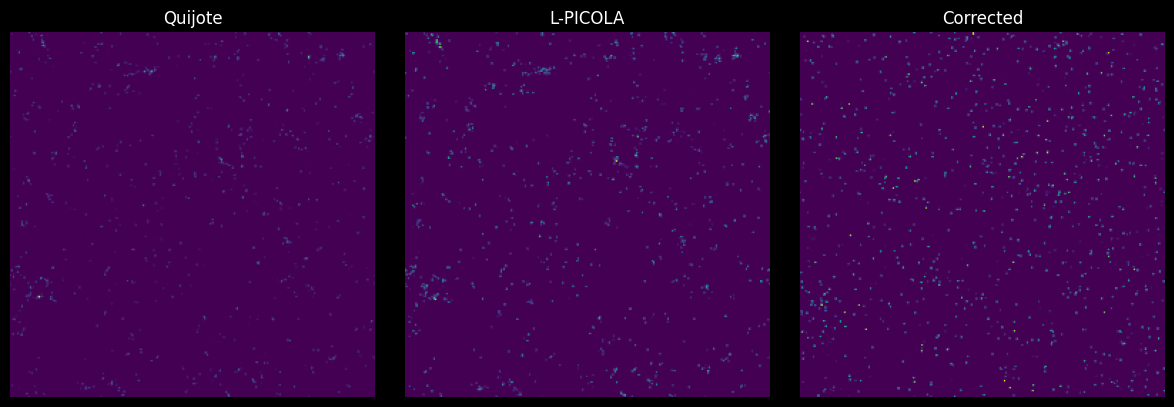

In [61]:
# N-body (=target if no emulator)
delta_halo_nn = get_delta(pos=pos_halo_nn.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_halo_nn, Pk_halo_nn, _, _ = compute_Pk(delta_halo_nn, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

delta_halo_interp = get_delta(pos=pos_halo_interp.astype("float32"), grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_halo_interp, Pk_halo_interp, _, _ = compute_Pk(delta_halo_interp, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# plt.imshow(delta[0])
ind=50
axes[0].imshow(delta_target[ind])
axes[0].set_title("Quijote")

axes[1].imshow(delta_pm[ind])
axes[1].set_title("L-PICOLA")


axes[2].imshow(delta_halo_interp[ind])
axes[2].set_title("Corrected")
# axes[2].imshow(delta_disp_interp[ind])
# axes[2].set_title("Corrected")

for ax in axes:
    ax.axis("off")

plt.tight_layout()  # Adjust layout
plt.show()
#plt.savefig(os.path.join(fig_fold, "corrected_slices.pdf"), bbox_inches = "tight")

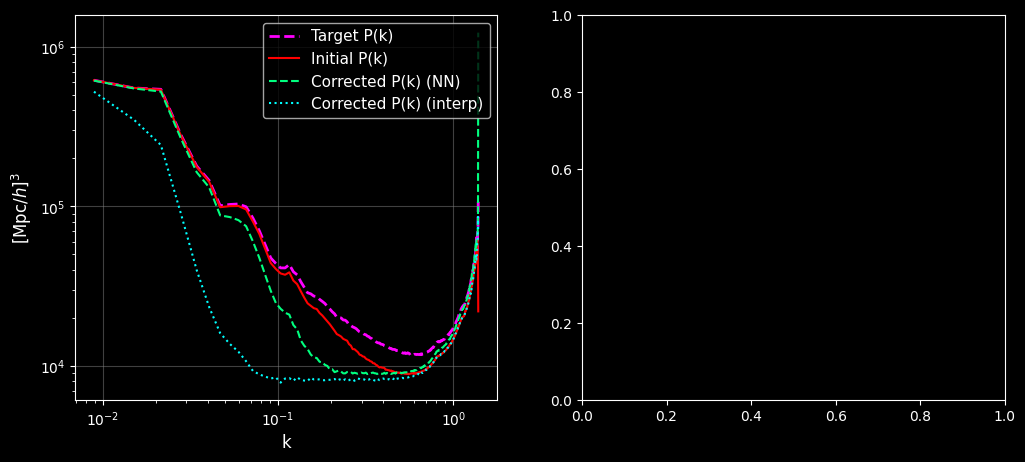

In [62]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

#summ_th =  coeffs[:,0]*(roots[:,1].real)**2+coeffs[:,1]*roots[:,1].real+ Pk_pm[inds]

ax1.plot(k, Pk0_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk0, color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
#ax1.plot(k, summ_th, color = "white", lw = 1.5, label = "Sum of terms", ls = "dotted", zorder = 5)
ax1.plot(k, Pk_halo_nn, color = "springgreen", lw = 1.5, label = "Corrected P(k) (NN)", ls = "dashed", zorder = 5)
ax1.plot(k, Pk_halo_interp, color = "aqua", lw = 1.5, label = "Corrected P(k) (interp)", ls = "dotted", zorder = 6)
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

# ax2.plot(k, Pk_target[inds]/Pk_target[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
# ax2.plot(k, Pk_pm[inds]/Pk_target[inds], color = "red", lw = 1.5, label = "Initial P(k)", zorder = 5)
# ax2.plot(k, summ_th/Pk_target[inds], color = "white", lw = 1.5, label = "Sum of terms", ls = "dotted", zorder = 10)
# ax2.plot(k, Pk_disp_nn[inds]/Pk_target[inds], color = "springgreen", lw = 1.5, label = "Corrected P(k) (NN)", ls = "dashed", zorder = 5)
# ax2.plot(k, Pk_disp_interp[inds]/Pk_target[inds], color = "aqua", lw = 1.5, label = "Corrected P(k) (interp)", ls = "dotted", zorder = 6)
# ax2.set_xlabel("k", fontsize =12)
# ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
# ax2.legend(fontsize = 11)
# ax2.set_xscale("log")
# ax2.set_yscale("log")
# ax2.grid(color = "grey", alpha = 0.5)
# plt.subplots_adjust(wspace = 0.3)
# plt.savefig(os.path.join(fig_fold, "Pk_disp_comparisons.pdf"), bbox_inches = "tight")
# plt.suptitle("Perfect correlation case, terms contribution")